<a href="https://colab.research.google.com/github/sagar0135/Dissertation/blob/main/KDD99_Combined_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [177]:
from sklearn.datasets import fetch_kddcup99

In [178]:
dataset = fetch_kddcup99()
dataset.data

array([[0, b'tcp', b'http', ..., 0.0, 0.0, 0.0],
       [0, b'tcp', b'http', ..., 0.0, 0.0, 0.0],
       [0, b'tcp', b'http', ..., 0.0, 0.0, 0.0],
       ...,
       [0, b'tcp', b'http', ..., 0.01, 0.0, 0.0],
       [0, b'tcp', b'http', ..., 0.01, 0.0, 0.0],
       [0, b'tcp', b'http', ..., 0.01, 0.0, 0.0]], dtype=object)

In [179]:
X = dataset.data  # Features
y = dataset.target  # Target variable

In [180]:
dataset = pd.DataFrame(data = np.c_[X, y], columns = dataset.feature_names + ["target"])

In [181]:
dataset = dataset.rename(columns= {"target": "attack_type"})

In [182]:
pd.set_option('display.max_columns', None)
dataset.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
0,0,b'tcp',b'http',b'SF',181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,b'normal.'
1,0,b'tcp',b'http',b'SF',239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,b'normal.'
2,0,b'tcp',b'http',b'SF',235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
3,0,b'tcp',b'http',b'SF',219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
4,0,b'tcp',b'http',b'SF',217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,b'normal.'


In [183]:
#isna() will check for null values and the sum() will add all the null values for each feature.

dataset.isna().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [184]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   duration                     494021 non-null  object
 1   protocol_type                494021 non-null  object
 2   service                      494021 non-null  object
 3   flag                         494021 non-null  object
 4   src_bytes                    494021 non-null  object
 5   dst_bytes                    494021 non-null  object
 6   land                         494021 non-null  object
 7   wrong_fragment               494021 non-null  object
 8   urgent                       494021 non-null  object
 9   hot                          494021 non-null  object
 10  num_failed_logins            494021 non-null  object
 11  logged_in                    494021 non-null  object
 12  num_compromised              494021 non-null  object
 13  root_shell    

In [185]:
#continouos_cols is a list of all continous dtype columns based on documentation.

continuous_cols = ["duration", "src_bytes", "dst_bytes", "wrong_fragment", "urgent", "hot", "num_failed_logins", "num_compromised", "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate"]
dataset[continuous_cols] = dataset[continuous_cols].apply(pd.to_numeric, errors='coerce')
len(continuous_cols)

32

In [186]:
#decode string columns from byte string to string.

columns_to_decode = ["protocol_type", "service", "flag", "attack_type"]

def decode_b_to_string(byte_str):
  return byte_str.decode('utf-8')

for i in columns_to_decode:
  dataset[i] = dataset[i].apply(decode_b_to_string)
  dataset[i] = dataset[i].astype('str')


In [187]:
#discrete_cols is a list of all discrete dtype columns based on documentation.

discrete_cols = ["src_bytes", "dst_bytes", "land", "logged_in", "root_shell", "su_attempted", "is_host_login", "is_guest_login"]
dataset[discrete_cols] = dataset[discrete_cols].apply(pd.to_numeric, errors='coerce')
len(discrete_cols)

8

In [188]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

In [189]:
dataset.nunique()

,0
duration,2495
protocol_type,3
service,66
flag,11
src_bytes,3300
dst_bytes,10725
land,2
wrong_fragment,3
urgent,4
hot,22


In [190]:
#split the data into training, testing and validation data. (70, 15, 15)

from sklearn.model_selection import train_test_split

trainData, tempData = train_test_split(dataset, test_size= 0.3, random_state= 42)
testData, valData = train_test_split(tempData, test_size= 0.5, random_state= 42)

In [191]:
trainData.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,345814.000000,3.458140e+05,3.458140e+05,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.0,345814.0,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000,345814.000000
mean,47.343638,3.671815e+03,8.430714e+02,0.000049,0.006428,0.000020,0.034455,0.000171,0.148082,0.010138,0.000104,0.000038,0.011506,0.001136,0.000104,0.001038,0.0,0.0,0.001408,332.168998,292.709095,0.177331,0.177242,0.057178,0.057488,0.791012,0.020999,0.029070,232.481201,188.547870,0.753410,0.030876,0.601495,0.006668,0.177404,0.177057,0.057884,0.057169
std,696.007371,1.180602e+06,3.082475e+04,0.007011,0.134337,0.006586,0.779755,0.015491,0.355182,1.707032,0.010203,0.008155,1.909044,0.108547,0.010203,0.037203,0.0,0.0,0.037501,213.141203,246.365834,0.381255,0.381545,0.231133,0.231708,0.388592,0.082149,0.142585,64.746723,106.098041,0.410979,0.108944,0.481394,0.042159,0.381134,0.381441,0.230115,0.229669
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,117.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,44.000000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,510.000000,510.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,511.000000,511.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.151154e+06,1.000000,3.000000,3.000000,30.000000,4.000000,1.000000,884.000000,1.000000,2.000000,993.000000,28.000000,1.000000,8.000000,0.0,0.0,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [192]:
# Convert relevant columns to numeric before calculating correlation
numeric_trainData = trainData.select_dtypes(include=['number'])
correlation_matrix = numeric_trainData.corr()

# Print or visualize the correlation matrix
print(correlation_matrix)
# Or you can visualize it using seaborn's heatmap:
# import seaborn as sns
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

                             duration  src_bytes  dst_bytes      land  \
duration                     1.000000   0.003731   0.004386 -0.000477   
src_bytes                    0.003731   1.000000  -0.000010 -0.000022   
dst_bytes                    0.004386  -0.000010   1.000000 -0.000192   
land                        -0.000477  -0.000022  -0.000192  1.000000   
wrong_fragment              -0.003255  -0.000142  -0.001309 -0.000336   
urgent                       0.004604  -0.000007   0.020869 -0.000022   
hot                          0.014504   0.004474   0.004713 -0.000310   
num_failed_logins            0.006759  -0.000032   0.075727 -0.000077   
logged_in                   -0.017554   0.001288   0.052358 -0.002923   
num_compromised              0.060487   0.000102   0.029453 -0.000042   
root_shell                   0.020363  -0.000024   0.046750 -0.000072   
su_attempted                 0.060041  -0.000011   0.105299 -0.000032   
num_root                     0.058764  -0.000012   

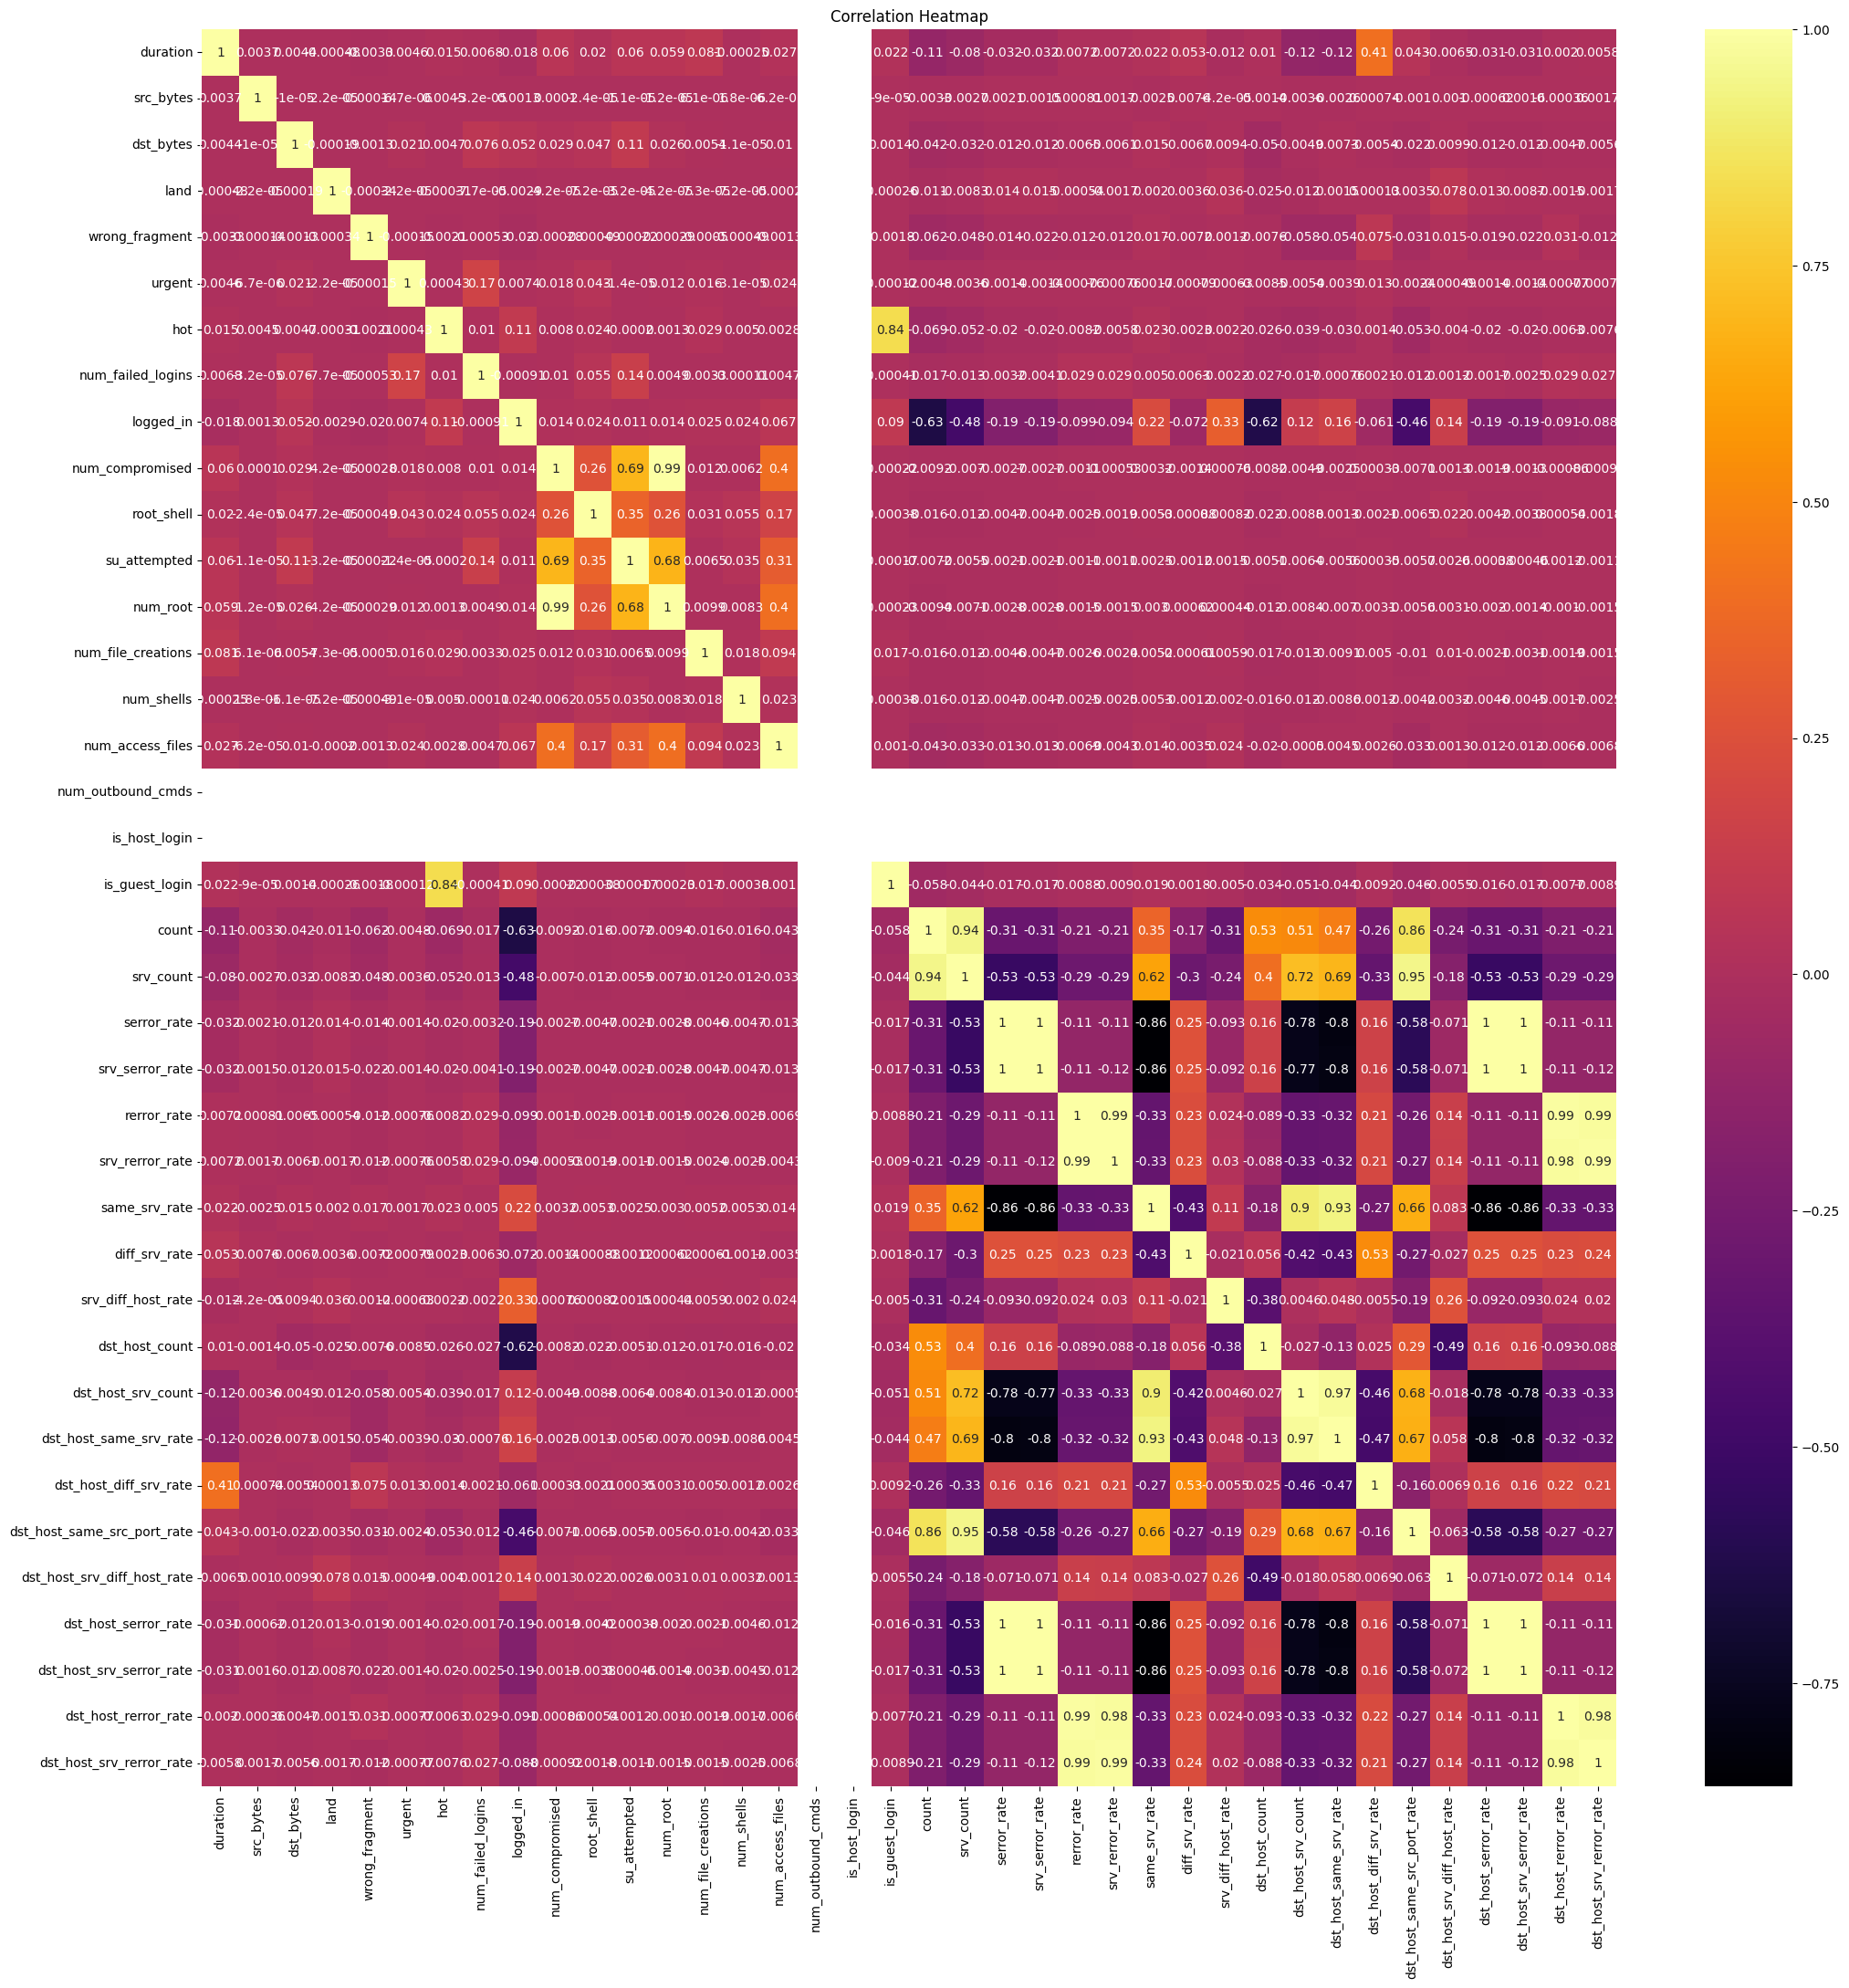

In [193]:
# We can clearly see 2 columns are redundant and some features are correlated more closely to other features.
# The yellow colour shows maximum correlation between features and as the color gets darker, correlation decreases.

plt.figure(figsize=(25,25))
# Select only numeric columns for correlation calculation
numeric_trainData = trainData.select_dtypes(include=['number'])
sns.heatmap(numeric_trainData.corr(), annot=True, cmap='inferno')
plt.title('Correlation Heatmap')
plt.show()

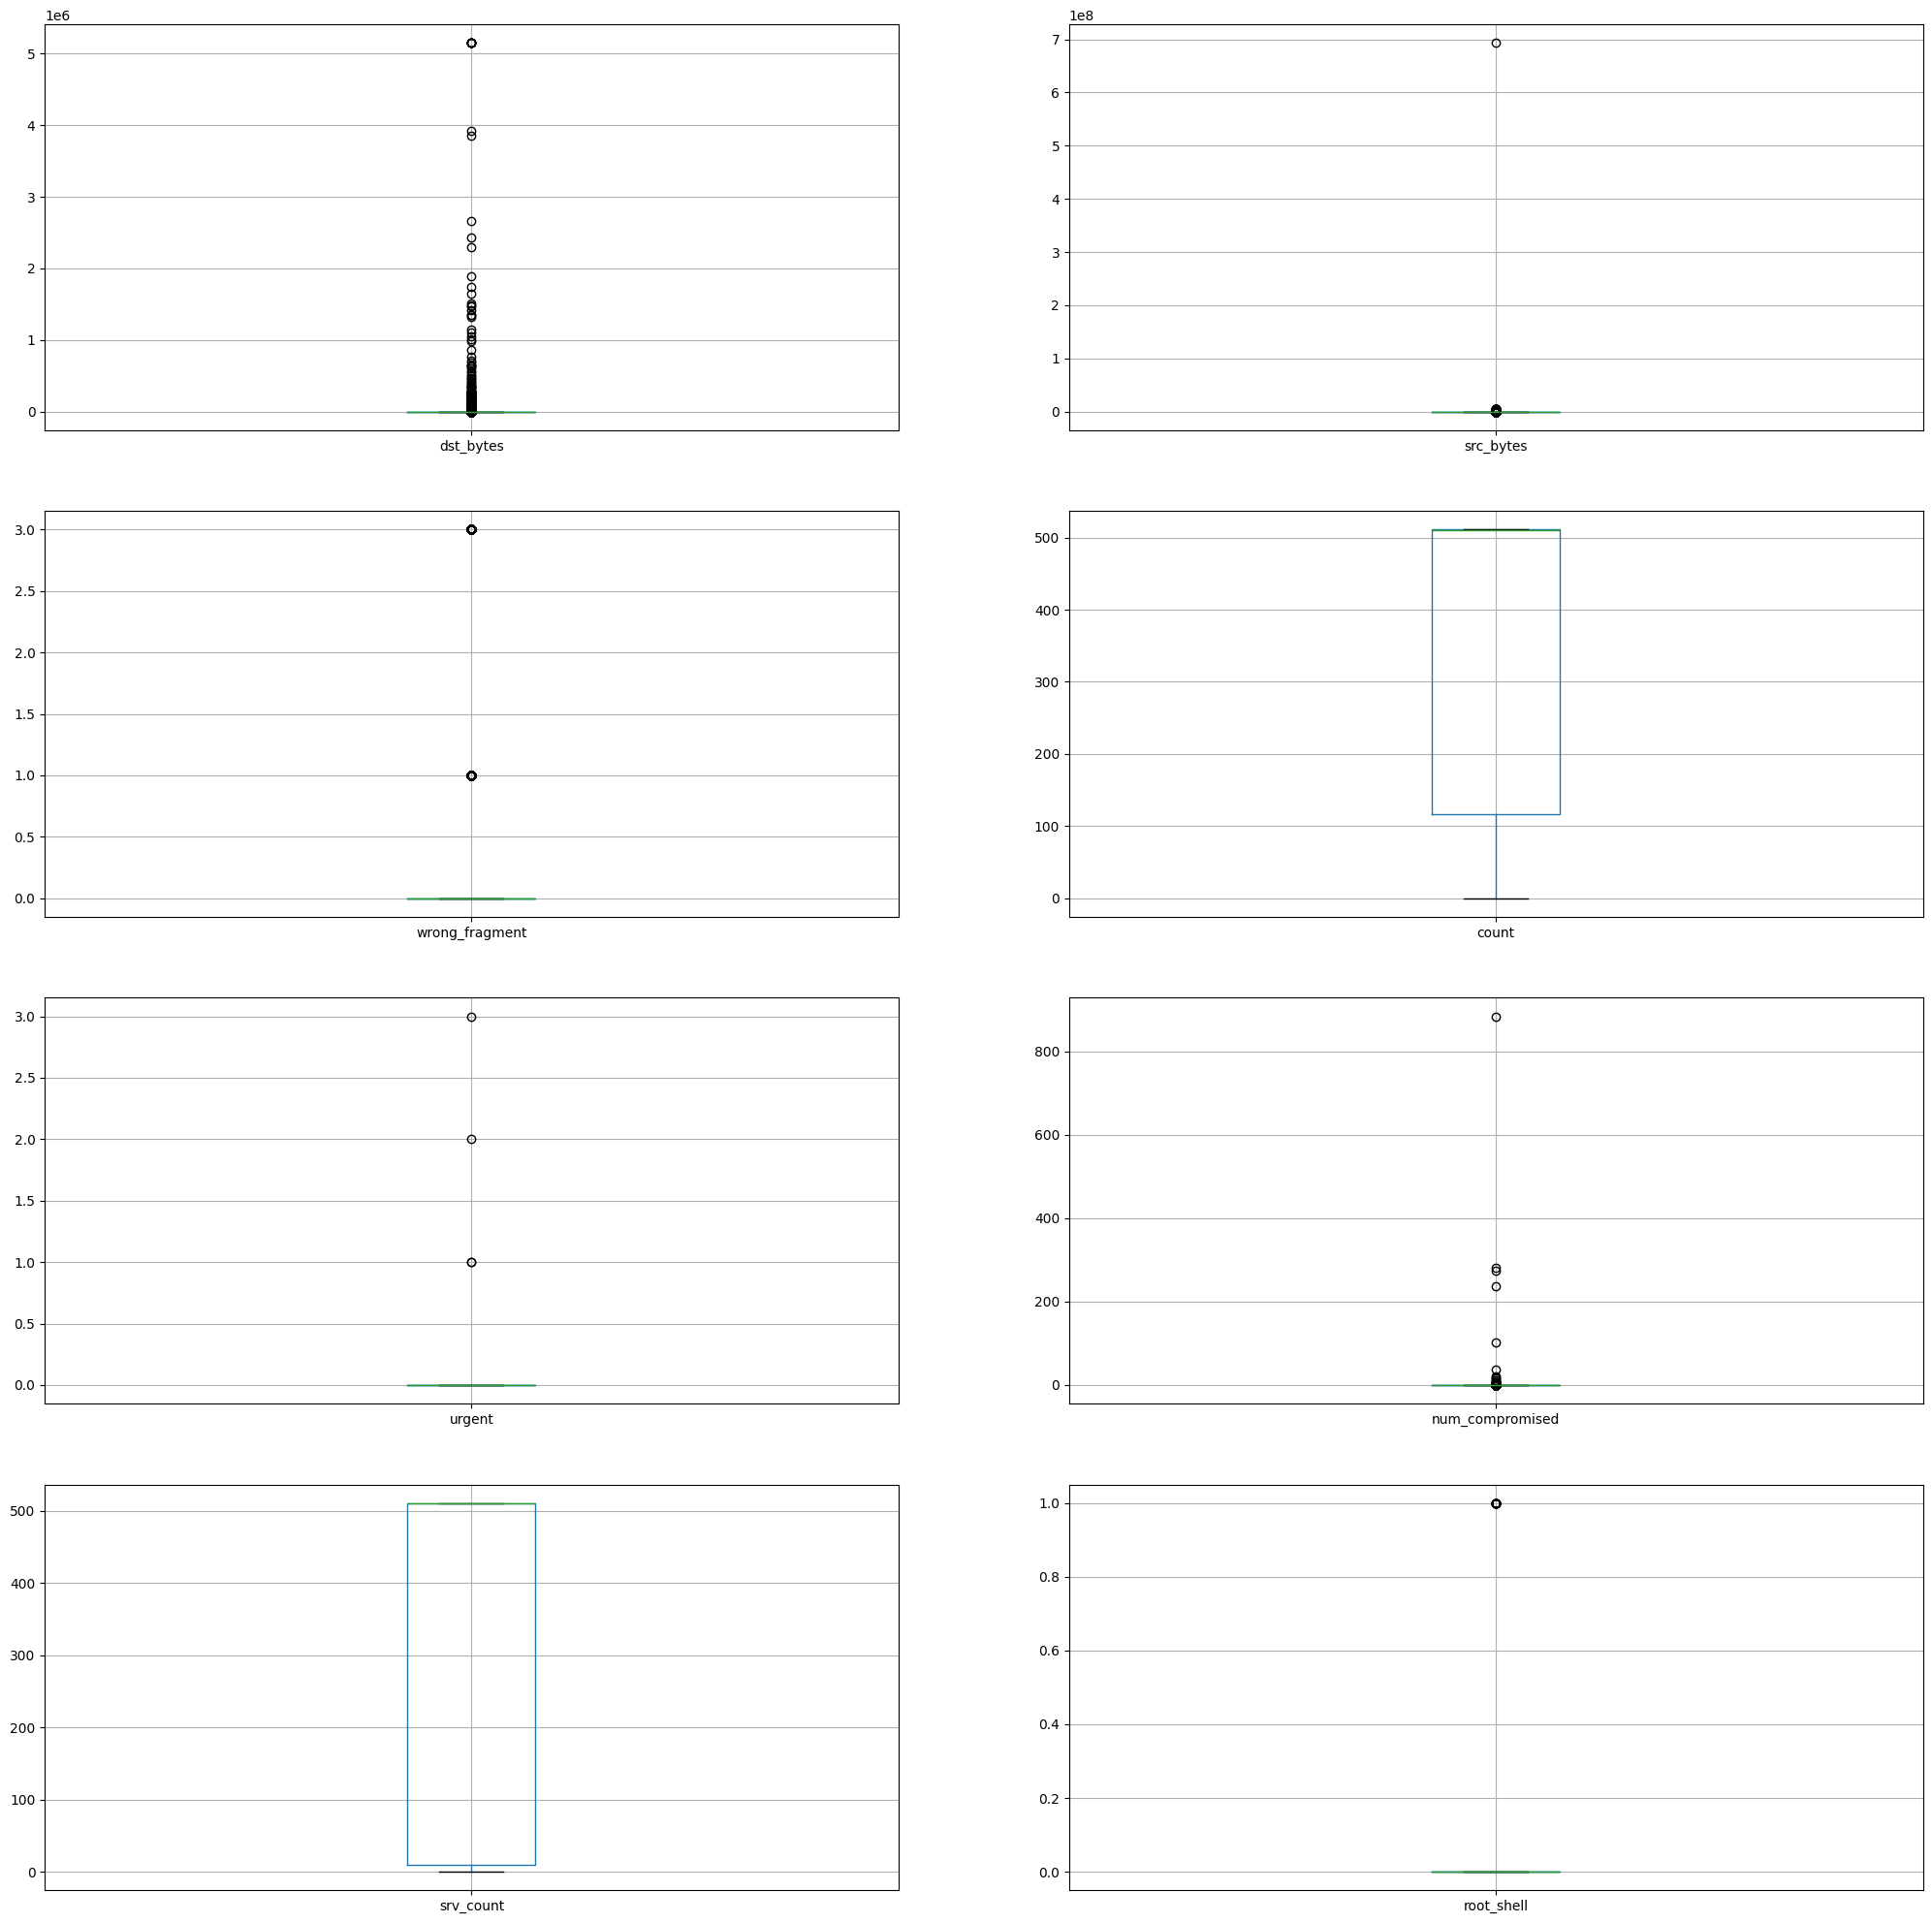

In [194]:
#boxplot for numeric values.

plt.figure(figsize=(25,25))

plt.subplot(4,2,1)
fig = trainData.boxplot(column='dst_bytes')

plt.subplot(4,2,2)
fig = trainData.boxplot(column='src_bytes')

plt.subplot(4,2,3)
fig = trainData.boxplot(column='wrong_fragment')

plt.subplot(4,2,4)
fig = trainData.boxplot(column='count')

plt.subplot(4,2,5)
fig = trainData.boxplot(column='urgent')

plt.subplot(4,2,6)
fig = trainData.boxplot(column='num_compromised')

plt.subplot(4,2,7)
fig = trainData.boxplot(column='srv_count')

plt.subplot(4,2,8)
fig = trainData.boxplot(column='root_shell')

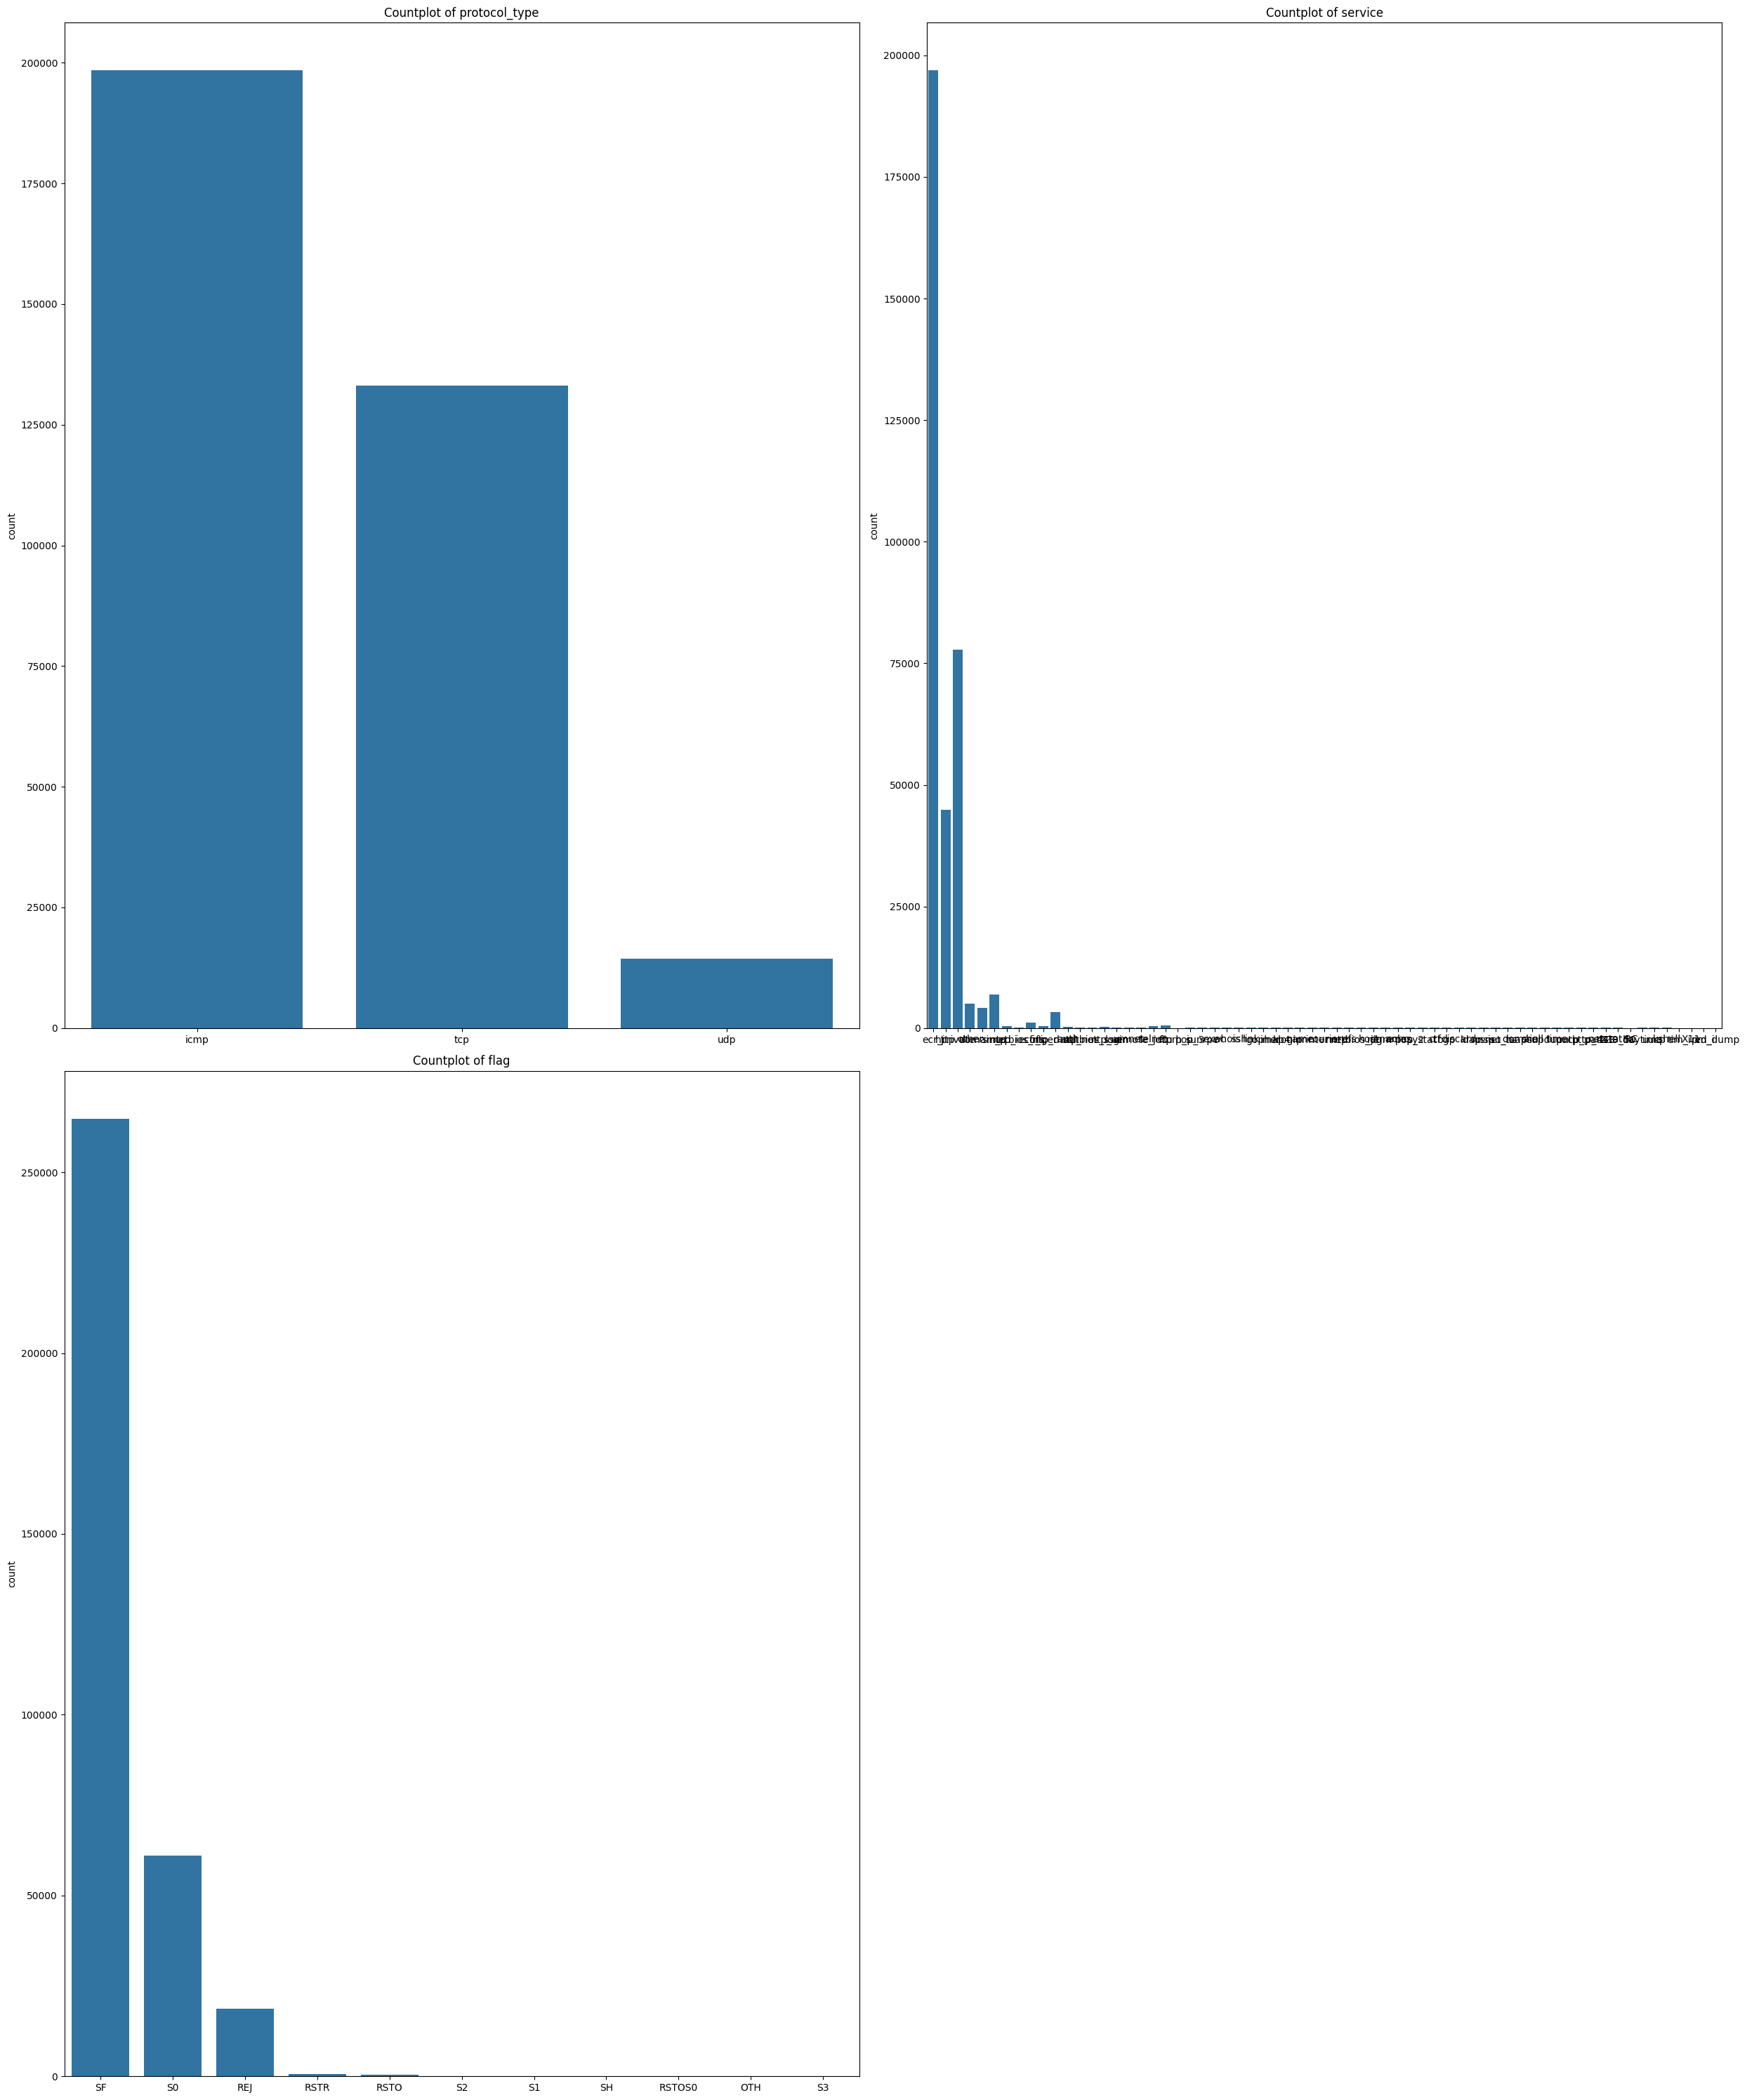

In [195]:
#visualise the categorical features.

columns_to_visualize = ["protocol_type", "service", "flag"]

# Set up the plot grid
num_plots = len(columns_to_visualize)
num_cols = 2  # Number of columns in the plot grid
num_rows = (num_plots + 1) // num_cols

plt.figure(figsize=(25, 30))

# Create countplots for each specified column
for i, column in enumerate(columns_to_visualize, start=1):
    plt.subplot(num_rows, num_cols, i)
    sns.countplot(data=trainData, x=column)
    plt.title(f'Countplot of {column}')
    plt.xlabel('')  # Optionally remove x-axis label for better visualization

plt.tight_layout()
plt.show()

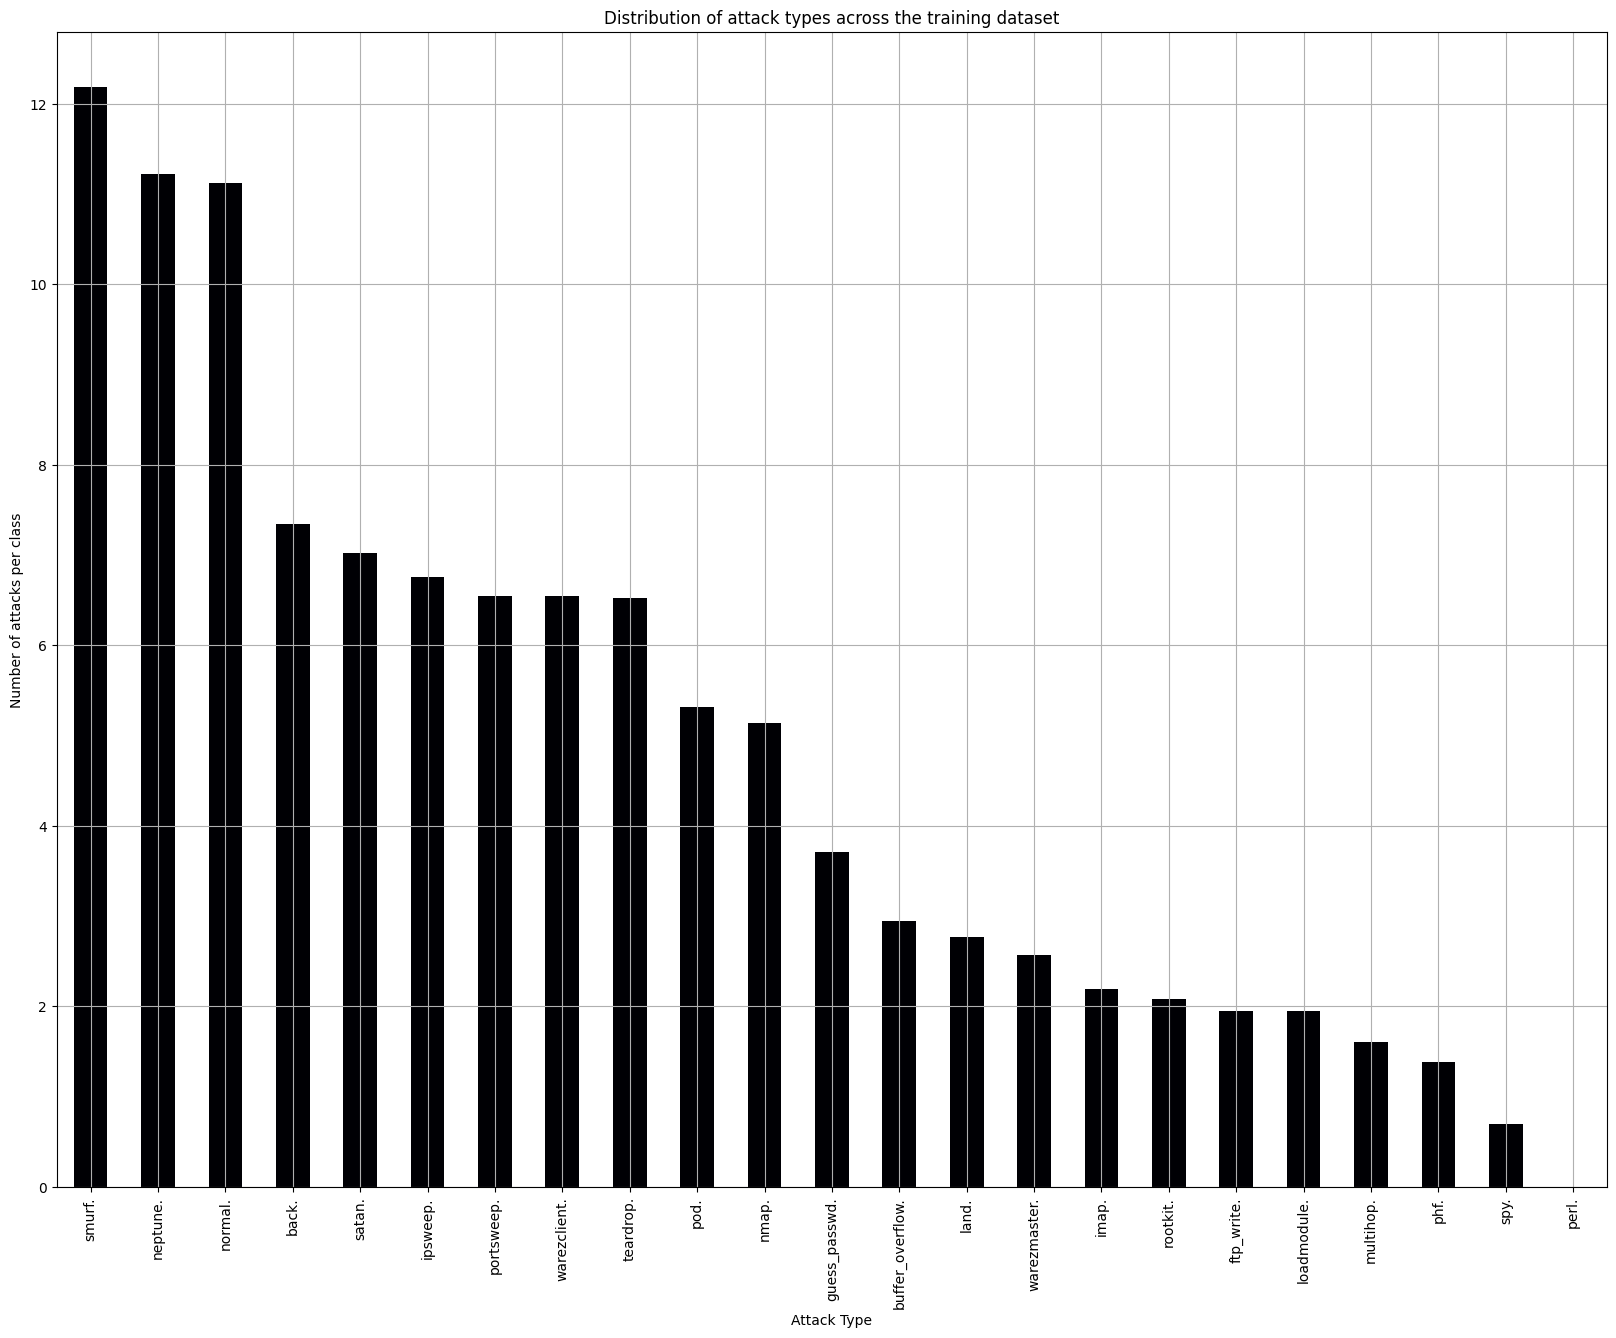

In [196]:
plt.figure(figsize=(20,15))
class_distribution = trainData["attack_type"].value_counts().apply(np.log)   #to reduce skewness of the data
class_distribution.plot(kind= "bar", cmap= "inferno")
plt.xlabel('Attack Type')
plt.ylabel('Number of attacks per class')
plt.title('Distribution of attack types across the training dataset')
plt.grid()
plt.show()

In [197]:
attackTypesCount = trainData["attack_type"].value_counts()
attackTypesCount.sum()

attackTypesCount.index

for i in range(len(attackTypesCount)):
  print(f"The class {attackTypesCount.index[i].capitalize()} has {attackTypesCount[i]} data points ({np.round((attackTypesCount[i]/attackTypesCount.sum()*100), 3)}%)")

The class Smurf. has 196420 data points (56.799%)
The class Neptune. has 75199 data points (21.746%)
The class Normal. has 68086 data points (19.689%)
The class Back. has 1546 data points (0.447%)
The class Satan. has 1120 data points (0.324%)
The class Ipsweep. has 862 data points (0.249%)
The class Portsweep. has 700 data points (0.202%)
The class Warezclient. has 696 data points (0.201%)
The class Teardrop. has 679 data points (0.196%)
The class Pod. has 204 data points (0.059%)
The class Nmap. has 170 data points (0.049%)
The class Guess_passwd. has 41 data points (0.012%)
The class Buffer_overflow. has 19 data points (0.005%)
The class Land. has 16 data points (0.005%)
The class Warezmaster. has 13 data points (0.004%)
The class Imap. has 9 data points (0.003%)
The class Rootkit. has 8 data points (0.002%)
The class Ftp_write. has 7 data points (0.002%)
The class Loadmodule. has 7 data points (0.002%)
The class Multihop. has 5 data points (0.001%)
The class Phf. has 4 data points 

# **Standard Scaler**

In [198]:
#select the numeric data from all three splits.

numerictrainData = trainData.select_dtypes(include=["int64", "float64"])
numerictestData = testData.select_dtypes(include=["int64", "float64"])
numericvalData = valData.select_dtypes(include=["int64", "float64"])

numericCols = trainData.select_dtypes(include=["int64", "float64"]).columns
numericCols

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# # Normalize the data
# min_max_scaler = MinMaxScaler()
# trainDataScaled = min_max_scaler.fit_transform(numerictrainData)
# testDataScaled = min_max_scaler.fit_transform(numerictestData)
# valDataScaled = min_max_scaler.fit_transform(numericvalData)

scaler = StandardScaler()
trainDataScaled = scaler.fit_transform(numerictrainData)
testDataScaled = scaler.fit_transform(numerictestData)
valDataScaled = scaler.fit_transform(numericvalData)

In [199]:
#convert them back to pandas dataframe

trainDataScaled = pd.DataFrame(data= trainDataScaled, columns= numericCols)
testDataScaled = pd.DataFrame(data= testDataScaled, columns= numericCols)
valDataScaled = pd.DataFrame(data= valDataScaled, columns= numericCols)

<Axes: xlabel='duration', ylabel='Count'>

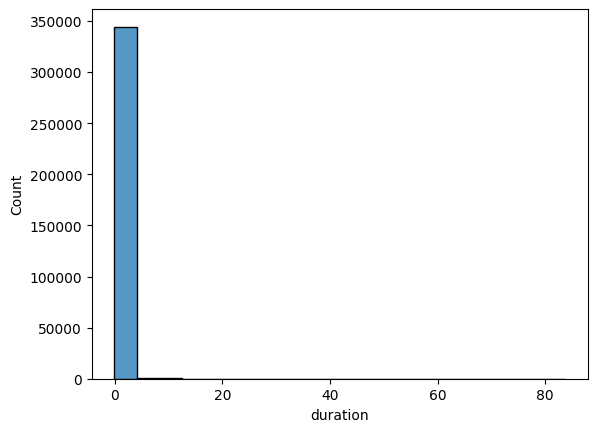

In [200]:
sns.histplot(data= trainDataScaled, x= "duration")

In [201]:
testDataScaled

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,-0.067174,-0.027602,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-1.093433,-1.178599,2.177586,2.176100,-0.248833,-0.249373,-1.974965,0.589338,-0.203422,0.351614,-1.757217,-1.819830,0.264545,-1.254133,-0.162474,2.178048,2.176882,-0.252596,-0.250506
1,-0.067174,-0.027602,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-0.990329,-1.158295,2.177586,2.176100,-0.248833,-0.249373,-1.871517,0.589338,-0.203422,0.351614,-1.709979,-1.771019,0.264545,-1.254133,-0.162474,2.178048,2.176882,-0.252596,-0.250506
2,-0.067174,-0.025883,-0.020792,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-1.552716,-1.186721,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.444041,0.425487,-0.189776,-1.254133,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506
3,-0.067174,-0.010705,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,0.837429,0.884278,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.623543,0.596326,-0.280640,0.824897,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506
4,-0.067174,-0.010705,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,0.837429,0.884278,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.623543,0.596326,-0.280640,0.824897,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74098,-0.067174,-0.010705,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,0.832743,0.880218,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.623543,0.596326,-0.280640,0.824897,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506
74099,-0.067174,-0.010705,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,0.837429,0.884278,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.623543,0.596326,-0.280640,0.824897,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506
74100,-0.067174,-0.027602,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-0.952837,-1.146113,2.177586,2.176100,-0.248833,-0.249373,-1.819793,0.348402,-0.203422,0.351614,-1.681637,-1.746613,0.264545,-1.254133,-0.162474,2.178048,2.176882,-0.252596,-0.250506
74101,-0.067174,-0.027602,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-0.273285,-1.162356,-0.460805,-0.460299,4.054962,4.046669,-1.974965,0.468870,-0.203422,0.351614,-1.719427,-1.771019,0.264545,-1.254133,-0.162474,-0.461102,-0.460007,4.071421,4.082564


In [202]:
valDataScaled

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,-0.067714,-0.022551,0.262012,-0.006363,-0.048366,0.0,-0.04404,-0.008999,2.399760,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,-1.478320,-1.119055,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,-3.355457,0.623975,0.599614,-0.282606,-1.127728,0.556275,-0.462845,-0.461832,-0.253786,-0.250945
1,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.836814,0.883499,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945
2,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.836814,0.883499,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945
3,-0.067714,-0.021965,0.001973,-0.006363,-0.048366,0.0,-0.04404,-0.008999,2.399760,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,-1.544064,-1.175922,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.614538,0.599614,-0.191637,-1.252409,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945
4,-0.067714,-0.028269,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,-0.262053,-1.143427,2.169816,2.167886,-0.249774,-0.250343,-1.938875,0.479926,-0.202697,0.345091,-1.669296,-1.712431,0.445142,-1.252409,-0.156982,2.170551,2.168664,-0.253786,-0.250945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74099,-0.067714,-0.028269,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,-1.022807,-1.175922,2.169816,2.167886,-0.249774,-0.250343,-1.964660,0.602383,-0.202697,0.345091,-1.744794,-1.785443,0.263205,-1.252409,-0.156982,2.170551,2.168664,-0.253786,-0.250945
74100,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.836814,0.883499,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945
74101,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.836814,0.883499,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945
74102,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.822726,0.871313,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945


In [203]:
trainData["attack_type"].value_counts()

,count
attack_type,
smurf.,196420
neptune.,75199
normal.,68086
back.,1546
satan.,1120
ipsweep.,862
portsweep.,700
warezclient.,696
teardrop.,679


In [204]:
trainData["attack_type"].unique()

array(['smurf.', 'normal.', 'neptune.', 'satan.', 'back.', 'portsweep.',
       'teardrop.', 'ipsweep.', 'warezclient.', 'pod.', 'guess_passwd.',
       'nmap.', 'land.', 'buffer_overflow.', 'ftp_write.', 'rootkit.',
       'phf.', 'imap.', 'warezmaster.', 'loadmodule.', 'multihop.',
       'spy.', 'perl.'], dtype=object)

In [205]:
trainData["attack_type"] = trainData["attack_type"].str.rstrip('.')
testData["attack_type"] = testData["attack_type"].str.rstrip('.')
valData["attack_type"] = valData["attack_type"].str.rstrip('.')

In [206]:
trainData["attack_type"].unique()

array(['smurf', 'normal', 'neptune', 'satan', 'back', 'portsweep',
       'teardrop', 'ipsweep', 'warezclient', 'pod', 'guess_passwd',
       'nmap', 'land', 'buffer_overflow', 'ftp_write', 'rootkit', 'phf',
       'imap', 'warezmaster', 'loadmodule', 'multihop', 'spy', 'perl'],
      dtype=object)

In [207]:
class_mapping = {
    'back': 'ANOMALY', 'buffer_overflow': 'ANOMALY', 'ftp_write': 'ANOMALY', 'guess_passwd': 'ANOMALY',
    'imap': 'ANOMALY', 'ipsweep': 'ANOMALY', 'land': 'ANOMALY', 'loadmodule': 'ANOMALY', 'multihop': 'ANOMALY',
    'neptune': 'ANOMALY', 'nmap': 'ANOMALY', 'perl': 'ANOMALY', 'phf': 'ANOMALY', 'pod': 'ANOMALY',
    'portsweep': 'ANOMALY', 'rootkit': 'ANOMALY', 'satan': 'ANOMALY', 'smurf': 'ANOMALY',
    'spy': 'ANOMALY', 'teardrop': 'ANOMALY', 'warezclient': 'ANOMALY', 'warezmaster': 'ANOMALY',
    'normal': 'NORMAL'
}

# Map the original classes to the smaller classes using the mapping dictionary
trainData["attack_type"] = trainData["attack_type"].map(class_mapping)

trainData["attack_type"].value_counts()

,count
attack_type,
ANOMALY,277728
NORMAL,68086


In [208]:
testData["attack_type"] = testData["attack_type"].map(class_mapping)

testData["attack_type"].value_counts()

,count
attack_type,
ANOMALY,59404
NORMAL,14699


In [209]:
valData["attack_type"] = valData["attack_type"].map(class_mapping)

valData["attack_type"].value_counts()

,count
attack_type,
ANOMALY,59611
NORMAL,14493


In [210]:
trainStrings = trainData.select_dtypes(include= 'object')
testStrings = testData.select_dtypes(include= 'object')
valStrings = valData.select_dtypes(include= 'object')

stringCols = trainData.select_dtypes(include= 'object').columns
stringCols

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

trainEncoded = trainStrings.apply(encoder.fit_transform)
testEncoded = testStrings.apply(encoder.fit_transform)
valEncoded = valStrings.apply(encoder.fit_transform)

In [211]:
trainData = pd.concat([trainDataScaled.reset_index(drop=True), trainEncoded.reset_index(drop=True)], axis=1)

In [212]:
trainData

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag,attack_type
0,-0.068022,-0.002236,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,0.839027,0.886045,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,0.347799,0.626328,0.600008,-0.283409,0.827815,-0.158160,-0.465464,-0.464180,-0.251545,-0.248922,0,14,9,0
1,-0.068022,-0.002900,0.083437,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,2.39854,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,-1.553756,-1.184050,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,-3.096396,0.626328,0.600008,-0.283409,-1.187169,1.265022,-0.465464,-0.464180,0.139565,-0.074758,1,22,9,1
2,-0.068022,-0.002236,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,0.834335,0.881986,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,0.347799,0.626328,0.600008,-0.283409,0.827815,-0.158160,-0.465464,-0.464180,-0.251545,-0.248922,0,14,9,0
3,-0.068022,-0.003110,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,-0.423049,-1.135342,2.157795,2.156388,-0.247383,-0.248104,-1.906919,0.596495,-0.203878,0.347799,-1.654584,-1.711552,0.359125,-1.249488,-0.158160,2.158291,2.157463,-0.251545,-0.248922,1,45,5,0
4,-0.068022,-0.003110,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,-0.568492,-1.159696,-0.465125,-0.464538,4.079128,4.067674,-1.958387,0.596495,-0.203878,0.347799,-1.711136,-1.760217,0.450916,-1.249488,-0.158160,-0.465464,-0.464180,4.094113,4.105184,1,45,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345809,-0.068022,-0.002236,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,0.839027,0.886045,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,0.347799,0.626328,0.600008,-0.283409,0.827815,-0.158160,-0.465464,-0.464180,-0.251545,-0.248922,0,14,9,0
345810,-0.068022,-0.003110,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,-1.065816,-1.167814,2.157795,2.156388,-0.247383,-0.248104,-1.906919,0.596495,-0.203878,0.347799,-1.701710,-1.760217,0.267334,-1.249488,-0.158160,2.158291,2.157463,-0.251545,-0.248922,1,45,5,0
345811,-0.068022,-0.002236,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,0.839027,0.886045,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,0.347799,0.626328,0.600008,-0.283409,0.827815,-0.158160,-0.465464,-0.464180,-0.251545,-0.248922,0,14,9,0
345812,13.065479,-0.002986,-0.023944,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,0.0,0.0,-0.037553,-1.553756,-1.184050,-0.465125,-0.464538,-0.247383,-0.248104,0

In [213]:
trainData["attack_type"].value_counts()

,count
attack_type,
0,277728
1,68086


In [214]:
testData = pd.concat([testDataScaled.reset_index(drop=True), testEncoded.reset_index(drop=True)], axis=1)

In [215]:
testData

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag,attack_type
0,-0.067174,-0.027602,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-1.093433,-1.178599,2.177586,2.176100,-0.248833,-0.249373,-1.974965,0.589338,-0.203422,0.351614,-1.757217,-1.819830,0.264545,-1.254133,-0.162474,2.178048,2.176882,-0.252596,-0.250506,1,37,5,0
1,-0.067174,-0.027602,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-0.990329,-1.158295,2.177586,2.176100,-0.248833,-0.249373,-1.871517,0.589338,-0.203422,0.351614,-1.709979,-1.771019,0.264545,-1.254133,-0.162474,2.178048,2.176882,-0.252596,-0.250506,1,44,5,0
2,-0.067174,-0.025883,-0.020792,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-1.552716,-1.186721,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.444041,0.425487,-0.189776,-1.254133,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506,2,44,9,1
3,-0.067174,-0.010705,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,0.837429,0.884278,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.623543,0.596326,-0.280640,0.824897,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506,0,14,9,0
4,-0.067174,-0.010705,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,0.837429,0.884278,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.623543,0.596326,-0.280640,0.824897,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506,0,14,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74098,-0.067174,-0.010705,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,0.832743,0.880218,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.623543,0.596326,-0.280640,0.824897,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506,0,14,9,0
74099,-0.067174,-0.010705,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,0.837429,0.884278,-0.460805,-0.460299,-0.248833,-0.249373,0.533656,-0.253938,-0.203422,0.351614,0.623543,0.596326,-0.280640,0.824897,-0.162474,-0.461102,-0.460007,-0.252596,-0.250506,0,14,9,0
74100,-0.067174,-0.027602,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-0.952837,-1.146113,2.177586,2.176100,-0.248833,-0.249373,-1.819793,0.348402,-0.203422,0.351614,-1.681637,-1.746613,0.264545,-1.254133,-0.162474,2.178048,2.176882,-0.252596,-0.250506,1,44,5,0
74101,-0.067174,-0.027602,-0.025036,-0.005195,-0.046451,0.0,-0.044032,-0.006707,-0.41894,-0.054592,-0.010391,0.0,-0.027725,-0.018475,-0.008572,-0.030407,0.0,0.0,-0.035639,-0.273285,-1.162356,-0.460805,-0.460299,4.054962,4.046669,-1.974965,0.468870,-0.203422,0.351614,-1.719427,-1.771019,0.264545,-1.254133,-0.162474,-0.4611

In [216]:
valData = pd.concat([valDataScaled.reset_index(drop=True), valEncoded.reset_index(drop=True)], axis=1)

In [217]:
valData

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag,attack_type
0,-0.067714,-0.022551,0.262012,-0.006363,-0.048366,0.0,-0.04404,-0.008999,2.399760,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,-1.478320,-1.119055,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,-3.355457,0.623975,0.599614,-0.282606,-1.127728,0.556275,-0.462845,-0.461832,-0.253786,-0.250945,1,22,8,1
1,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.836814,0.883499,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945,0,14,8,0
2,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.836814,0.883499,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945,0,14,8,0
3,-0.067714,-0.021965,0.001973,-0.006363,-0.048366,0.0,-0.04404,-0.008999,2.399760,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,-1.544064,-1.175922,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.614538,0.599614,-0.191637,-1.252409,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945,1,22,8,1
4,-0.067714,-0.028269,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,-0.262053,-1.143427,2.169816,2.167886,-0.249774,-0.250343,-1.938875,0.479926,-0.202697,0.345091,-1.669296,-1.712431,0.445142,-1.252409,-0.156982,2.170551,2.168664,-0.253786,-0.250945,1,44,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74099,-0.067714,-0.028269,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,-1.022807,-1.175922,2.169816,2.167886,-0.249774,-0.250343,-1.964660,0.602383,-0.202697,0.345091,-1.744794,-1.785443,0.263205,-1.252409,-0.156982,2.170551,2.168664,-0.253786,-0.250945,1,44,4,0
74100,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.836814,0.883499,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945,0,14,8,0
74101,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.836814,0.883499,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.623975,0.599614,-0.282606,0.825621,-0.156982,-0.462845,-0.461832,-0.253786,-0.250945,0,14,8,0
74102,-0.067714,-0.006655,-0.024412,-0.006363,-0.048366,0.0,-0.04404,-0.008999,-0.416708,-0.005413,-0.012185,-0.006942,-0.005267,-0.015188,-0.010434,-0.024005,0.0,0.0,-0.037489,0.822726,0.871313,-0.462535,-0.461988,-0.249774,-0.250343,0.536483,-0.254821,-0.202697,0.345091,0.6

In [218]:
trainData = trainData.drop(columns= ["num_outbound_cmds", "is_host_login"], axis= 1)
testData = testData.drop(columns= ["num_outbound_cmds", "is_host_login"], axis= 1)
valData = valData.drop(columns= ["num_outbound_cmds", "is_host_login"], axis= 1)

In [219]:
X_train = trainData.iloc[:, :-1]
y_train = trainData.iloc[:, -1]

X_test = testData.iloc[:, :-1]
y_test = testData.iloc[:, -1]

X_val = valData.iloc[:, :-1]
y_val = valData.iloc[:, -1]

In [220]:
y_train.unique()

array([0, 1])

In [221]:
#run the model without any hyperparameter tuning or reduced number of features.

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_jobs= -1, n_estimators= 50)

rfc.fit(X_train, y_train) #training the model using normal data

y_predRFC = rfc.predict(X_val)  #predict on validation data

In [222]:
from sklearn.metrics import accuracy_score

raw_training_accuracy = accuracy_score(y_train, rfc.predict(X_train))
print(f"The training score of the model is: {raw_training_accuracy*100}%")

from sklearn.metrics import accuracy_score

rfc_val_accuracy = accuracy_score(y_val, y_predRFC)

print(f"The accuracy on validation data without hyperparameter tuning for classifying the connections using RandomForestClassifier is: {rfc_val_accuracy*100}%")

The training score of the model is: 99.99942165441537%
The accuracy on validation data without hyperparameter tuning for classifying the connections using RandomForestClassifier is: 42.81955090143582%


In [223]:
y_pred_testRFC = rfc.predict(X_test)

rfc_test_accuracy = accuracy_score(y_test, y_pred_testRFC)

print(f"The accuracy on testing data without hyperparameter tuning for classifying the connections using RandomForestClassifier is: {rfc_test_accuracy*100}%")

The accuracy on testing data without hyperparameter tuning for classifying the connections using RandomForestClassifier is: 42.82417715881948%


In [224]:
rfc2 = RandomForestClassifier(n_jobs= -1, n_estimators= 50)


from sklearn.feature_selection import SelectKBest, f_classif

featureSelector = SelectKBest(score_func= f_classif, k= 20)

X_trainSelected = featureSelector.fit_transform(X_train, y_train)

X_testSelected = featureSelector.transform(X_test)

X_valSelected = featureSelector.transform(X_val)

selected_features_indices = featureSelector.get_support(indices=True)

# Get the selected feature names (assuming X_train is a DataFrame)
selected_feature_names = trainData.columns[selected_features_indices]

In [225]:
selected_feature_names

Index(['duration', 'logged_in', 'num_access_files', 'count', 'srv_count',
       'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'protocol_type', 'service', 'flag'],
      dtype='object')

In [226]:
X_trainSelected = pd.DataFrame(data= X_trainSelected, columns= selected_feature_names)
X_testSelected = pd.DataFrame(data= X_testSelected, columns= selected_feature_names)
X_valSelected = pd.DataFrame(data= X_valSelected, columns= selected_feature_names)

In [227]:
#using the selected features to train the RFC.

rfc2.fit(X_trainSelected, y_train)

y_pred_selectedRFC = rfc2.predict(X_valSelected)

raw_selected_training_accuracy = rfc2.score(X_trainSelected, y_train)
print(f"The training score of the model is: {raw_selected_training_accuracy*100}%")

from sklearn.metrics import accuracy_score

rfc_raw_accuracy_selected = accuracy_score(y_val, y_pred_selectedRFC)

print(f"The accuracy on the validation data after feature selection for classifying the connections using RandomForestClassifier is: {rfc_raw_accuracy_selected*100}%")

The training score of the model is: 99.74466042438999%
The accuracy on the validation data after feature selection for classifying the connections using RandomForestClassifier is: 99.61135701176724%


In [228]:
y_pred_selectedRFC_testData = rfc2.predict(X_testSelected)

rfc_test_accuracy_selected = accuracy_score(y_test, y_pred_selectedRFC_testData)

print(f"The accuracy on the testing data after feature selection for classifying the connections using RandomForestClassifier is: {rfc_test_accuracy_selected*100}%")

The accuracy on the testing data after feature selection for classifying the connections using RandomForestClassifier is: 99.65993279624307%


In [229]:
y_train.value_counts()

,count
attack_type,
0,277728
1,68086


In [230]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from collections import Counter



# # Assuming X contains features and y contains target variable


# min_samples = min(Counter(y).values())

# # Define the pipeline with SMOTE and RandomOverSampler
# pipeline = Pipeline([
#     ('sampling', SMOTE(sampling_strategy='auto', k_neighbors=min_samples, random_state=42)
#                  if min_samples >= 5 else RandomOverSampler(sampling_strategy='auto', random_state=42))
# ])

# # Fit and transform the data using the pipeline
# X_trainResampled, y_trainResampled = pipeline.fit_resample(X_train, y_train)

In [231]:
def oversample_to_ratio(X, y, target_ratio):
    # Calculate the number of samples needed for the minority class
    minority_class = 1  # Assuming class 1 is the minority class
    unique_classes = sorted(Counter(y).items())
    minority_count = [count for cls, count in unique_classes if cls == minority_class][0]
    majority_count = [count for cls, count in unique_classes if cls != minority_class][0]

    # Calculate the desired number of samples for the minority class based on the target ratio
    target_minority_count = int(majority_count * target_ratio / (1 - target_ratio))
    minority_samples_needed = target_minority_count - minority_count

    # Apply SMOTE if more samples are needed for the minority class
    if minority_samples_needed > 0:
        smote = SMOTE(sampling_strategy={minority_class: minority_samples_needed})
        X_resampled, y_resampled = smote.fit_resample(X, y)
        return X_resampled, y_resampled
    else:
        return X, y  # No oversampling needed

X_trainResampled, y_trainResampled = oversample_to_ratio(X_train, y_train, 0.45)  #0.45 for a training:testing split of 45:55.

In [232]:
y_trainResampled.value_counts()

,count
attack_type,
0,277728
1,159146


In [233]:
X_trainResampled

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag
0,-0.068022,-0.002236,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,0.839027,0.886045,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,0.347799,0.626328,0.600008,-0.283409,0.827815,-0.158160,-0.465464,-0.464180,-0.251545,-0.248922,0,14,9
1,-0.068022,-0.002900,0.083437,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,2.39854,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,-1.553756,-1.184050,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,-3.096396,0.626328,0.600008,-0.283409,-1.187169,1.265022,-0.465464,-0.464180,0.139565,-0.074758,1,22,9
2,-0.068022,-0.002236,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,0.834335,0.881986,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,0.347799,0.626328,0.600008,-0.283409,0.827815,-0.158160,-0.465464,-0.464180,-0.251545,-0.248922,0,14,9
3,-0.068022,-0.003110,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,-0.423049,-1.135342,2.157795,2.156388,-0.247383,-0.248104,-1.906919,0.596495,-0.203878,0.347799,-1.654584,-1.711552,0.359125,-1.249488,-0.158160,2.158291,2.157463,-0.251545,-0.248922,1,45,5
4,-0.068022,-0.003110,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,-0.568492,-1.159696,-0.465125,-0.464538,4.079128,4.067674,-1.958387,0.596495,-0.203878,0.347799,-1.711136,-1.760217,0.450916,-1.249488,-0.158160,-0.465464,-0.464180,4.094113,4.105184,1,45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436869,-0.068022,-0.002890,-0.015444,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,2.39854,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,-1.553756,-1.184050,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,-0.203878,0.347799,0.626328,0.600008,-0.283409,-1.249488,-0.158160,-0.465464,-0.464180,-0.251545,-0.248922,1,22,9
436870,-0.066345,-0.000006,-0.016629,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,2.39854,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,-1.553756,-1.179991,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,6.809516,-1.814476,-0.069596,-0.004229,0.251986,-1.228715,0.079037,-0.443614,-0.464180,-0.251545,-0.248922,1,50,9
436871,-0.068022,-0.003110,-0.027351,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,-0.41692,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,-1.553756,-1.179991,-0.465125,-0.464538,4.079128,4.067674,0.537809,-0.255620,6.809516,-3.424540,0.617791,0.600008,-0.283409,-1.049587,3.399794,-0.465464,-0.464180,4.094113,4.105184,1,22,1
436872,-0.068022,-0.002919,-0.006695,-0.007012,-0.047852,-0.003073,-0.044187,-0.011013,2.39854,-0.005939,-0.010204,-0.00461,-0.006027,-0.01047,-0.010204,-0.027905,-0.037553,-1.520914,-1.151578,-0.465125,-0.464538,-0.247383,-0.248104,0.537809,-0.255620,1.339068,-2.924199,0.626328,0.600008,-0.283409,-1.207942,0.079037,-0.465464,-0.464180,-0.251545,-0.248922,1,22,9


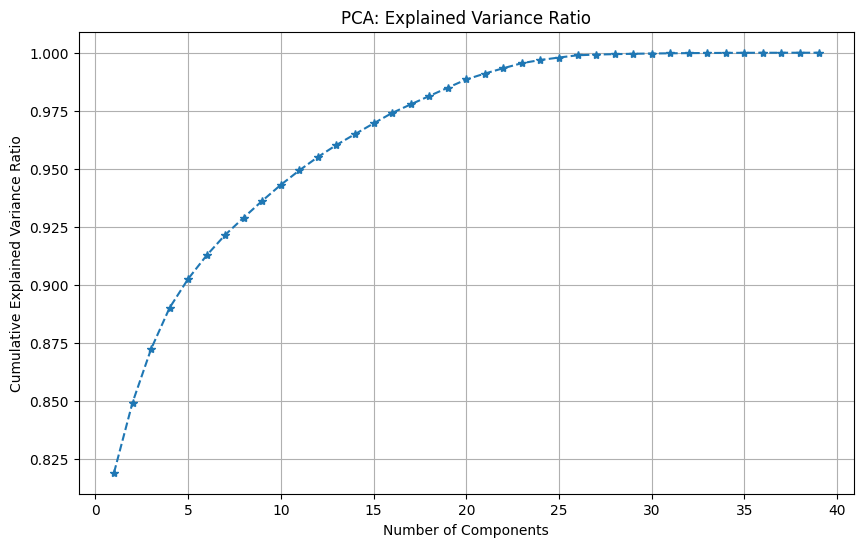

In [234]:
from sklearn.decomposition import PCA

# # Assuming 'X' contains your features
# pca = PCA(n_components= 23)
# pca.fit(X_train)

pca = PCA()
pca.fit(X_trainResampled)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_.cumsum(), marker='*', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA: Explained Variance Ratio')
plt.grid(True)
plt.show()

In [235]:
#apply the optimal n_components to a new pca.
#optimal number would be something where the graph levels off.
#in our case we might wanna keep it to 95% explained variance because at the point of 20 components, it's giving unnatural results.

#components = 11
components = 25

pca = PCA(n_components= components)

X_train_pca = pca.fit_transform(X_trainResampled)   #resampled and pca both done.
X_test_pca = pca.transform(X_test)
X_val_pca = pca.transform(X_val)

In [236]:
X_val_pca

array([[-2.15084086e+00,  1.06162151e+00, -3.22234876e+00, ...,
         2.53345870e-01, -1.15849017e-01,  2.73456004e-01],
       [-1.03666368e+01, -8.74770607e-01,  1.23948803e+00, ...,
         3.14410233e-02,  1.17059200e-01,  1.50498534e-01],
       [-1.03666368e+01, -8.74770607e-01,  1.23948803e+00, ...,
         3.14410233e-02,  1.17059200e-01,  1.50498534e-01],
       ...,
       [-1.03666368e+01, -8.74770607e-01,  1.23948803e+00, ...,
         3.14410233e-02,  1.17059200e-01,  1.50498534e-01],
       [-1.03653787e+01, -8.73196859e-01,  1.23240325e+00, ...,
         3.03726336e-02,  1.10862381e-01,  1.50551973e-01],
       [ 2.06559906e+01, -1.33255810e+00,  2.77987470e+00, ...,
         6.44816006e-04, -2.33487794e-02,  1.96373140e-01]])

In [237]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score,roc_curve
from sklearn.model_selection import cross_val_score


def model_eval(model,X_train, y_train, X_val, y_val, X_test, y_test):
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

    print(f"ROC AUC: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

    #calculate training accuracy
    trainPred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, trainPred)
    print(f"\nThe training accuracy of the model will be: {np.round(accuracy_score(y_train, trainPred), 3)*100}%\n")

    #calculate validation accuracy
    valPred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, valPred)
    print(f"The validation accuracy of the model will be: {np.round(accuracy_score(y_val, valPred), 3)*100}%\n")

    testPred = model.predict(X_test)

    model_name = type(model).__name__

    print(f"{model_name} testing report on unseen data")
    print(classification_report(y_test, testPred))
    print("The confusion matrix will be: \n")
    print(confusion_matrix(y_test, testPred))
    print(f"The ROC-AUC score on the testing data will be: {np.round(roc_auc_score(y_test, testPred), 3)}\n")


    fpr, tpr, thresholds = roc_curve(y_test, testPred)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    print(f"\nThe testing accuracy of the model on unseen data will be: {np.round(accuracy_score(y_test, testPred), 3)*100}%\n")

ROC AUC: 0.9985 (+/- 0.0001)


The training accuracy of the model will be: 99.2%

The validation accuracy of the model will be: 99.1%

LogisticRegression testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     59404
           1       0.97      0.99      0.98     14699

    accuracy                           0.99     74103
   macro avg       0.98      0.99      0.99     74103
weighted avg       0.99      0.99      0.99     74103

The confusion matrix will be: 

[[58940   464]
 [   82 14617]]
The ROC-AUC score on the testing data will be: 0.993


The testing accuracy of the model on unseen data will be: 99.3%



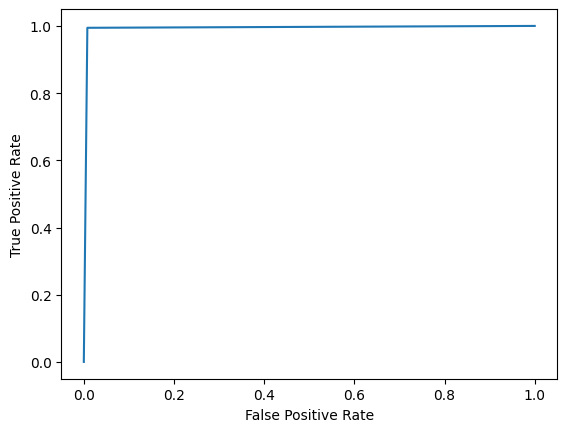

In [238]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression

# Calculate class weights for imbalance handling
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

# Initialize and train Logistic Regression model
lrL2 = LogisticRegression(penalty='l2', C=1.0, class_weight=dict(enumerate(class_weights)), random_state=42)
lrL2.fit(X_train_pca, y_trainResampled)

model_eval(lrL2, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)


ROC AUC: 0.9996 (+/- 0.0001)


The training accuracy of the model will be: 100.0%

The validation accuracy of the model will be: 99.8%

XGBClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59404
           1       0.99      1.00      0.99     14699

    accuracy                           1.00     74103
   macro avg       0.99      1.00      1.00     74103
weighted avg       1.00      1.00      1.00     74103

The confusion matrix will be: 

[[59230   174]
 [   18 14681]]
The ROC-AUC score on the testing data will be: 0.998


The testing accuracy of the model on unseen data will be: 99.7%



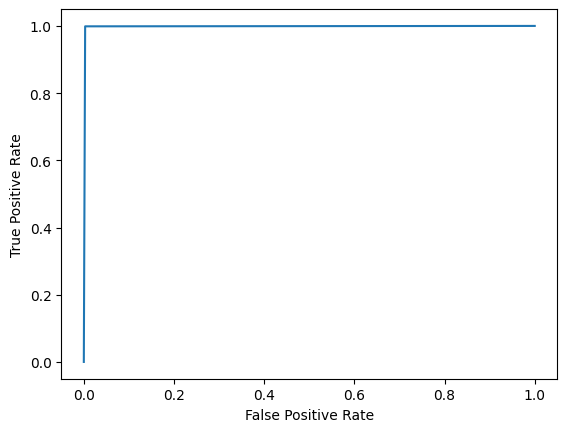

In [239]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:hinge", random_state=42)
xgb_model.fit(X_train_pca, y_trainResampled)

model_eval(xgb_model, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

ROC AUC: 0.9994 (+/- 0.0001)


The training accuracy of the model will be: 100.0%

The validation accuracy of the model will be: 99.7%

DecisionTreeClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59404
           1       0.99      1.00      1.00     14699

    accuracy                           1.00     74103
   macro avg       1.00      1.00      1.00     74103
weighted avg       1.00      1.00      1.00     74103

The confusion matrix will be: 

[[59305    99]
 [   44 14655]]
The ROC-AUC score on the testing data will be: 0.998


The testing accuracy of the model on unseen data will be: 99.8%



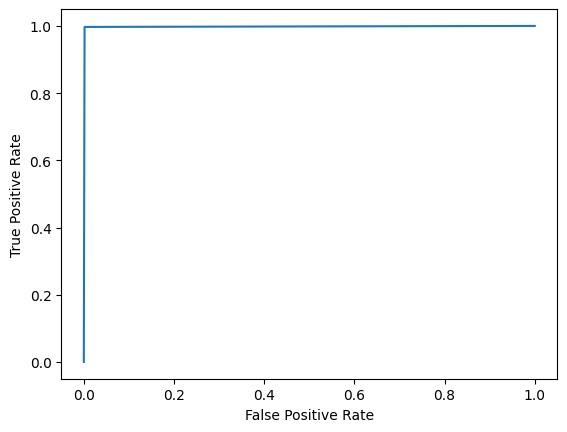

In [240]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train_pca, y_trainResampled)

model_eval(dtc, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

ROC AUC: 0.9868 (+/- 0.0002)


The training accuracy of the model will be: 92.9%

The validation accuracy of the model will be: 92.30000000000001%

BernoulliNB testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     59404
           1       0.59      1.00      0.74     14699

    accuracy                           0.86     74103
   macro avg       0.79      0.91      0.82     74103
weighted avg       0.92      0.86      0.87     74103

The confusion matrix will be: 

[[49250 10154]
 [   53 14646]]
The ROC-AUC score on the testing data will be: 0.913


The testing accuracy of the model on unseen data will be: 86.2%



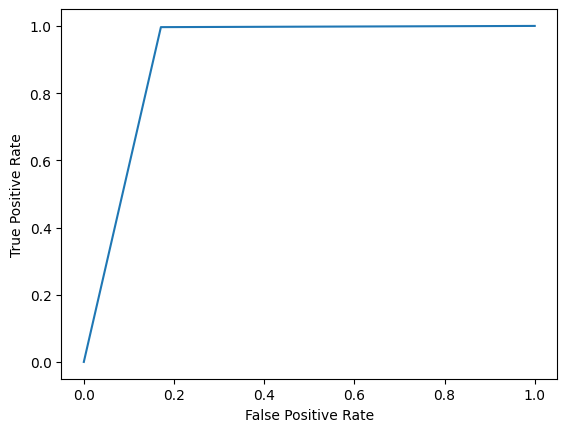

In [241]:
from sklearn.naive_bayes import BernoulliNB

# Train Gaussian Naive Baye Model
BNB_Classifier = BernoulliNB()
BNB_Classifier.fit(X_train_pca, y_trainResampled)

model_eval(BNB_Classifier, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

ROC AUC: 1.0000 (+/- 0.0000)


The training accuracy of the model will be: 100.0%

The validation accuracy of the model will be: 99.9%

RandomForestClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     59404
           1       0.97      1.00      0.99     14699

    accuracy                           0.99     74103
   macro avg       0.99      1.00      0.99     74103
weighted avg       0.99      0.99      0.99     74103

The confusion matrix will be: 

[[59021   383]
 [    6 14693]]
The ROC-AUC score on the testing data will be: 0.997


The testing accuracy of the model on unseen data will be: 99.5%



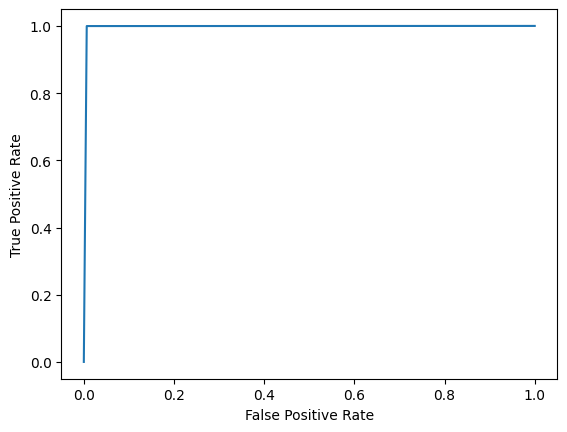

In [242]:
from sklearn.ensemble import RandomForestClassifier

rfcFinal = RandomForestClassifier(n_jobs= -1, n_estimators= 35, criterion= "entropy")
rfcFinal.fit(X_train_pca, y_trainResampled)

model_eval(rfcFinal, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

ROC AUC: 0.9992 (+/- 0.0001)


The training accuracy of the model will be: 99.3%

The validation accuracy of the model will be: 99.6%

LinearSVC testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     59404
           1       0.97      1.00      0.99     14699

    accuracy                           0.99     74103
   macro avg       0.99      0.99      0.99     74103
weighted avg       0.99      0.99      0.99     74103

The confusion matrix will be: 

[[59024   380]
 [   65 14634]]
The ROC-AUC score on the testing data will be: 0.995


The testing accuracy of the model on unseen data will be: 99.4%



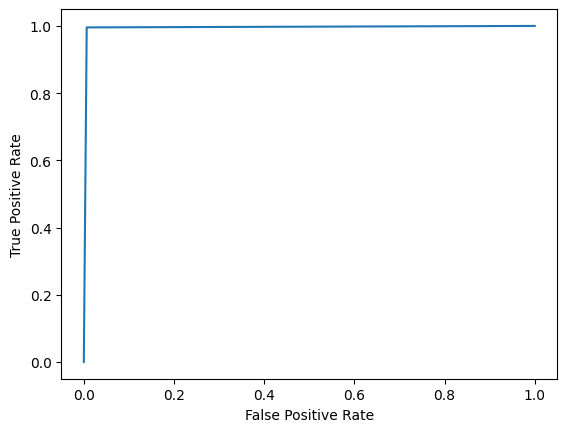

In [243]:
from sklearn.svm import LinearSVC

newSVM = LinearSVC()
newSVM.fit(X_train_pca, y_trainResampled)

model_eval(newSVM, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

# **Robust Scaler**

In [244]:
#split the data into training, testing and validation data. (70, 15, 15)

from sklearn.model_selection import train_test_split

trainData, tempData = train_test_split(dataset, test_size= 0.3, random_state= 42)
testData, valData = train_test_split(tempData, test_size= 0.5, random_state= 42)

In [245]:
#select the numeric data from all three splits.

numerictrainData = trainData.select_dtypes(include=["int64", "float64"])
numerictestData = testData.select_dtypes(include=["int64", "float64"])
numericvalData = valData.select_dtypes(include=["int64", "float64"])

numericCols = trainData.select_dtypes(include=["int64", "float64"]).columns
numericCols

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# # Normalize the data
# min_max_scaler = MinMaxScaler()
# trainDataScaled = min_max_scaler.fit_transform(numerictrainData)
# testDataScaled = min_max_scaler.fit_transform(numerictestData)
# valDataScaled = min_max_scaler.fit_transform(numericvalData)

scaler = RobustScaler()
trainDataScaled = scaler.fit_transform(numerictrainData)
testDataScaled = scaler.fit_transform(numerictestData)
valDataScaled = scaler.fit_transform(numericvalData)

In [246]:
#convert them back to pandas dataframe

trainDataScaled = pd.DataFrame(data= trainDataScaled, columns= numericCols)
testDataScaled = pd.DataFrame(data= testDataScaled, columns= numericCols)
valDataScaled = pd.DataFrame(data= valDataScaled, columns= numericCols)

<Axes: xlabel='duration', ylabel='Count'>

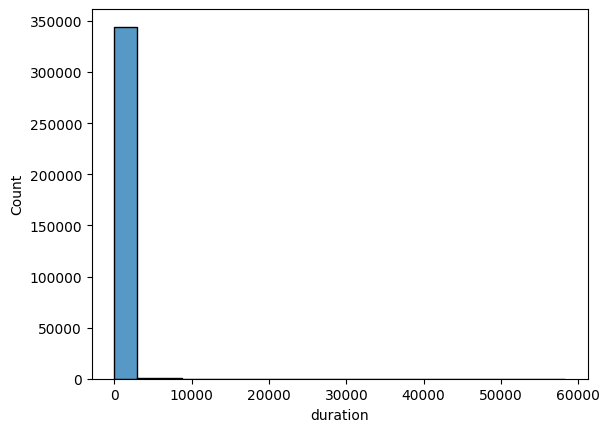

In [247]:
sns.histplot(data= trainDataScaled, x= "duration")

In [248]:
testDataScaled

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.0,-0.527383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.040506,-1.011976,1.0,1.0,0.0,0.0,-0.97,0.07,0.0,0.0,-1.235294,-1.833333,1.50,-1.0,0.0,1.0,1.0,0.0,0.0
1,0.0,-0.527383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.984810,-1.001996,1.0,1.0,0.0,0.0,-0.93,0.07,0.0,0.0,-1.210784,-1.796296,1.50,-1.0,0.0,1.0,1.0,0.0,0.0
2,0.0,-0.420892,146.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.288608,-1.015968,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,-0.093137,-0.129630,0.25,-1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.519270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002532,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.519270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002532,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74098,0.0,0.519270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0
74099,0.0,0.519270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002532,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0
74100,0.0,-0.527383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.964557,-0.996008,1.0,1.0,0.0,0.0,-0.91,0.05,0.0,0.0,-1.196078,-1.777778,1.50,-1.0,0.0,1.0,1.0,0.0,0.0
74101,0.0,-0.527383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.597468,-1.003992,0.0,0.0,1.0,1.0,-0.97,0.06,0.0,0.0,-1.215686,-1.796296,1.50,-1.0,0.0,0.0,0.0,1.0,1.0


In [249]:
valDataScaled

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.0,-0.250253,11670.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.248731,-0.982036,0.0,0.0,0.0,0.0,0.00,0.00,0.0,-237.0,0.000000,0.000000,0.00,-0.94,0.03,0.0,0.0,0.0,0.0
1,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0
2,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0
3,0.0,-0.221884,1075.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.284264,-1.009980,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,-0.004808,0.000000,0.25,-1.00,0.00,0.0,0.0,0.0,0.0
4,0.0,-0.526849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.591371,-0.994012,1.0,1.0,0.0,0.0,-0.96,0.06,0.0,0.0,-1.168269,-1.583333,2.00,-1.00,0.00,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74099,0.0,-0.526849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.002538,-1.009980,1.0,1.0,0.0,0.0,-0.97,0.07,0.0,0.0,-1.206731,-1.633333,1.50,-1.00,0.00,1.0,1.0,0.0,0.0
74100,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0
74101,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0
74102,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.005076,-0.003992,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0


In [250]:
trainData["attack_type"].value_counts()

,count
attack_type,
smurf.,196420
neptune.,75199
normal.,68086
back.,1546
satan.,1120
ipsweep.,862
portsweep.,700
warezclient.,696
teardrop.,679


In [251]:
trainData["attack_type"].unique()

array(['smurf.', 'normal.', 'neptune.', 'satan.', 'back.', 'portsweep.',
       'teardrop.', 'ipsweep.', 'warezclient.', 'pod.', 'guess_passwd.',
       'nmap.', 'land.', 'buffer_overflow.', 'ftp_write.', 'rootkit.',
       'phf.', 'imap.', 'warezmaster.', 'loadmodule.', 'multihop.',
       'spy.', 'perl.'], dtype=object)

In [252]:
trainData["attack_type"] = trainData["attack_type"].str.rstrip('.')
testData["attack_type"] = testData["attack_type"].str.rstrip('.')
valData["attack_type"] = valData["attack_type"].str.rstrip('.')

In [253]:
trainData["attack_type"].unique()

array(['smurf', 'normal', 'neptune', 'satan', 'back', 'portsweep',
       'teardrop', 'ipsweep', 'warezclient', 'pod', 'guess_passwd',
       'nmap', 'land', 'buffer_overflow', 'ftp_write', 'rootkit', 'phf',
       'imap', 'warezmaster', 'loadmodule', 'multihop', 'spy', 'perl'],
      dtype=object)

In [254]:
class_mapping = {
    'back': 'ANOMALY', 'buffer_overflow': 'ANOMALY', 'ftp_write': 'ANOMALY', 'guess_passwd': 'ANOMALY',
    'imap': 'ANOMALY', 'ipsweep': 'ANOMALY', 'land': 'ANOMALY', 'loadmodule': 'ANOMALY', 'multihop': 'ANOMALY',
    'neptune': 'ANOMALY', 'nmap': 'ANOMALY', 'perl': 'ANOMALY', 'phf': 'ANOMALY', 'pod': 'ANOMALY',
    'portsweep': 'ANOMALY', 'rootkit': 'ANOMALY', 'satan': 'ANOMALY', 'smurf': 'ANOMALY',
    'spy': 'ANOMALY', 'teardrop': 'ANOMALY', 'warezclient': 'ANOMALY', 'warezmaster': 'ANOMALY',
    'normal': 'NORMAL'
}

# Map the original classes to the smaller classes using the mapping dictionary
trainData["attack_type"] = trainData["attack_type"].map(class_mapping)

trainData["attack_type"].value_counts()

,count
attack_type,
ANOMALY,277728
NORMAL,68086


In [255]:
testData["attack_type"] = testData["attack_type"].map(class_mapping)

testData["attack_type"].value_counts()

,count
attack_type,
ANOMALY,59404
NORMAL,14699


In [256]:
valData["attack_type"] = valData["attack_type"].map(class_mapping)

valData["attack_type"].value_counts()

,count
attack_type,
ANOMALY,59611
NORMAL,14493


In [257]:
trainStrings = trainData.select_dtypes(include= 'object')
testStrings = testData.select_dtypes(include= 'object')
valStrings = valData.select_dtypes(include= 'object')

stringCols = trainData.select_dtypes(include= 'object').columns
stringCols

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

trainEncoded = trainStrings.apply(encoder.fit_transform)
testEncoded = testStrings.apply(encoder.fit_transform)
valEncoded = valStrings.apply(encoder.fit_transform)

In [258]:
trainData = pd.concat([trainDataScaled.reset_index(drop=True), trainEncoded.reset_index(drop=True)], axis=1)

In [259]:
trainData

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag,attack_type
0,0.0,0.518219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0,14,9,0
1,0.0,-0.275304,3415.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.291878,-1.015968,0.0,0.0,0.0,0.0,0.00,0.00,0.0,-223.0,0.000000,0.000000,0.00,-0.97,0.06,0.0,0.0,0.09,0.04,1,22,9,1
2,0.0,0.518219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0,14,9,0
3,0.0,-0.526316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.680203,-0.992016,1.0,1.0,0.0,0.0,-0.95,0.07,0.0,0.0,-1.146919,-1.583333,1.75,-1.00,0.00,1.0,1.0,0.00,0.00,1,45,5,0
4,0.0,-0.526316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.758883,-1.003992,0.0,0.0,1.0,1.0,-0.97,0.07,0.0,0.0,-1.175355,-1.616667,2.00,-1.00,0.00,0.0,0.0,1.00,1.00,1,45,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345809,0.0,0.518219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0,14,9,0
345810,0.0,-0.526316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.027919,-1.007984,1.0,1.0,0.0,0.0,-0.95,0.07,0.0,0.0,-1.170616,-1.616667,1.50,-1.00,0.00,1.0,1.0,0.00,0.00,1,45,5,0
345811,0.0,0.518219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0,14,9,0
345812,9141.0,-0.377530,105.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.291878,-1.015968,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,-1.194313,-1.650000,10.25,-0.16,0.00,0.0,0.0,0.00,0.00,2,40,9,1


In [260]:
testData = pd.concat([testDataScaled.reset_index(drop=True), testEncoded.reset_index(drop=True)], axis=1)

In [261]:
testData

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag,attack_type
0,0.0,-0.527383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.040506,-1.011976,1.0,1.0,0.0,0.0,-0.97,0.07,0.0,0.0,-1.235294,-1.833333,1.50,-1.0,0.0,1.0,1.0,0.0,0.0,1,37,5,0
1,0.0,-0.527383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.984810,-1.001996,1.0,1.0,0.0,0.0,-0.93,0.07,0.0,0.0,-1.210784,-1.796296,1.50,-1.0,0.0,1.0,1.0,0.0,0.0,1,44,5,0
2,0.0,-0.420892,146.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.288608,-1.015968,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,-0.093137,-0.129630,0.25,-1.0,0.0,0.0,0.0,0.0,0.0,2,44,9,1
3,0.0,0.519270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002532,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,14,9,0
4,0.0,0.519270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002532,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,14,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74098,0.0,0.519270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,14,9,0
74099,0.0,0.519270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002532,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,14,9,0
74100,0.0,-0.527383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.964557,-0.996008,1.0,1.0,0.0,0.0,-0.91,0.05,0.0,0.0,-1.196078,-1.777778,1.50,-1.0,0.0,1.0,1.0,0.0,0.0,1,44,5,0
74101,0.0,-0.527383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.597468,-1.003992,0.0,0.0,1.0,1.0,-0.97,0.06,0.0,0.0,-1.215686,-1.796296,1.50,-1.0,0.0,0.0,0.0,1.0,1.0,1,44,1,0


In [262]:
valData = pd.concat([valDataScaled.reset_index(drop=True), valEncoded.reset_index(drop=True)], axis=1)

In [263]:
valData

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag,attack_type
0,0.0,-0.250253,11670.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.248731,-0.982036,0.0,0.0,0.0,0.0,0.00,0.00,0.0,-237.0,0.000000,0.000000,0.00,-0.94,0.03,0.0,0.0,0.0,0.0,1,22,8,1
1,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0,14,8,0
2,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0,14,8,0
3,0.0,-0.221884,1075.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.284264,-1.009980,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,-0.004808,0.000000,0.25,-1.00,0.00,0.0,0.0,0.0,0.0,1,22,8,1
4,0.0,-0.526849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.591371,-0.994012,1.0,1.0,0.0,0.0,-0.96,0.06,0.0,0.0,-1.168269,-1.583333,2.00,-1.00,0.00,1.0,1.0,0.0,0.0,1,44,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74099,0.0,-0.526849,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.002538,-1.009980,1.0,1.0,0.0,0.0,-0.97,0.07,0.0,0.0,-1.206731,-1.633333,1.50,-1.00,0.00,1.0,1.0,0.0,0.0,1,44,4,0
74100,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0,14,8,0
74101,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0,14,8,0
74102,0.0,0.518744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.005076,-0.003992,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0,14,8,0


In [264]:
trainData = trainData.drop(columns= ["num_outbound_cmds", "is_host_login"], axis= 1)
testData = testData.drop(columns= ["num_outbound_cmds", "is_host_login"], axis= 1)
valData = valData.drop(columns= ["num_outbound_cmds", "is_host_login"], axis= 1)

In [265]:
X_train = trainData.iloc[:, :-1]
y_train = trainData.iloc[:, -1]

X_test = testData.iloc[:, :-1]
y_test = testData.iloc[:, -1]

X_val = valData.iloc[:, :-1]
y_val = valData.iloc[:, -1]

In [266]:
y_train.unique()

array([0, 1])

In [267]:
#run the model without any hyperparameter tuning or reduced number of features.

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_jobs= -1, n_estimators= 50)

rfc.fit(X_train, y_train) #training the model using normal data

y_predRFC = rfc.predict(X_val)  #predict on validation data

In [268]:
from sklearn.metrics import accuracy_score

raw_training_accuracy = accuracy_score(y_train, rfc.predict(X_train))
print(f"The training score of the model is: {raw_training_accuracy*100}%")

from sklearn.metrics import accuracy_score

rfc_val_accuracy = accuracy_score(y_val, y_predRFC)

print(f"The accuracy on validation data without hyperparameter tuning for classifying the connections using RandomForestClassifier is: {rfc_val_accuracy*100}%")

The training score of the model is: 99.99971082720769%
The accuracy on validation data without hyperparameter tuning for classifying the connections using RandomForestClassifier is: 99.9716614487747%


In [269]:
y_pred_testRFC = rfc.predict(X_test)

rfc_test_accuracy = accuracy_score(y_test, y_pred_testRFC)

print(f"The accuracy on testing data without hyperparameter tuning for classifying the connections using RandomForestClassifier is: {rfc_test_accuracy*100}%")

The accuracy on testing data without hyperparameter tuning for classifying the connections using RandomForestClassifier is: 99.97705895847672%


In [270]:
rfc2 = RandomForestClassifier(n_jobs= -1, n_estimators= 50)


from sklearn.feature_selection import SelectKBest, f_classif

featureSelector = SelectKBest(score_func= f_classif, k= 20)

X_trainSelected = featureSelector.fit_transform(X_train, y_train)

X_testSelected = featureSelector.transform(X_test)

X_valSelected = featureSelector.transform(X_val)

selected_features_indices = featureSelector.get_support(indices=True)

# Get the selected feature names (assuming X_train is a DataFrame)
selected_feature_names = trainData.columns[selected_features_indices]

In [271]:
selected_feature_names

Index(['duration', 'logged_in', 'num_access_files', 'count', 'srv_count',
       'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'protocol_type', 'service', 'flag'],
      dtype='object')

In [272]:
X_trainSelected = pd.DataFrame(data= X_trainSelected, columns= selected_feature_names)
X_testSelected = pd.DataFrame(data= X_testSelected, columns= selected_feature_names)
X_valSelected = pd.DataFrame(data= X_valSelected, columns= selected_feature_names)

In [273]:
#using the selected features to train the RFC.

rfc2.fit(X_trainSelected, y_train)

y_pred_selectedRFC = rfc2.predict(X_valSelected)

raw_selected_training_accuracy = rfc2.score(X_trainSelected, y_train)
print(f"The training score of the model is: {raw_selected_training_accuracy*100}%")

from sklearn.metrics import accuracy_score

rfc_raw_accuracy_selected = accuracy_score(y_val, y_pred_selectedRFC)

print(f"The accuracy on the validation data after feature selection for classifying the connections using RandomForestClassifier is: {rfc_raw_accuracy_selected*100}%")

The training score of the model is: 99.7449495971823%
The accuracy on the validation data after feature selection for classifying the connections using RandomForestClassifier is: 99.62350210514953%


In [274]:
y_pred_selectedRFC_testData = rfc2.predict(X_testSelected)

rfc_test_accuracy_selected = accuracy_score(y_test, y_pred_selectedRFC_testData)

print(f"The accuracy on the testing data after feature selection for classifying the connections using RandomForestClassifier is: {rfc_test_accuracy_selected*100}%")

The accuracy on the testing data after feature selection for classifying the connections using RandomForestClassifier is: 99.65318543108917%


In [275]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from collections import Counter



# # Assuming X contains features and y contains target variable

# min_samples = min(Counter(y).values())

# # Define the pipeline with SMOTE and RandomOverSampler
# pipeline = Pipeline([
#     ('sampling', SMOTE(sampling_strategy='auto', k_neighbors=min_samples, random_state=42)
#                  if min_samples >= 5 else RandomOverSampler(sampling_strategy='auto', random_state=42))
# ])

# # Fit and transform the data using the pipeline
# X_trainResampled, y_trainResampled = pipeline.fit_resample(X_train, y_train)

In [276]:
def oversample_to_ratio(X, y, target_ratio):
    # Calculate the number of samples needed for the minority class
    minority_class = 1  # Assuming class 1 is the minority class
    unique_classes = sorted(Counter(y).items())
    minority_count = [count for cls, count in unique_classes if cls == minority_class][0]
    majority_count = [count for cls, count in unique_classes if cls != minority_class][0]

    # Calculate the desired number of samples for the minority class based on the target ratio
    target_minority_count = int(majority_count * target_ratio / (1 - target_ratio))
    minority_samples_needed = target_minority_count - minority_count

    # Apply SMOTE if more samples are needed for the minority class
    if minority_samples_needed > 0:
        smote = SMOTE(sampling_strategy={minority_class: minority_samples_needed})
        X_resampled, y_resampled = smote.fit_resample(X, y)
        return X_resampled, y_resampled
    else:
        return X, y  # No oversampling needed

X_trainResampled, y_trainResampled = oversample_to_ratio(X_train, y_train, 0.45)  #0.45 for a split between the 2 different classes of 45:55.

In [277]:
y_trainResampled.value_counts()

,count
attack_type,
0,277728
1,159146


In [278]:
X_trainResampled

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag
0,0.000000,0.518219,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002538,0.001996,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.00,0.00,0,14,9
1,0.000000,-0.275304,3415.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.291878,-1.015968,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,-223.000000,0.000000,0.000000,0.000000,-0.97,0.060000,0.000000,0.0,0.09,0.04,1,22,9
2,0.000000,0.518219,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.00,0.00,0,14,9
3,0.000000,-0.526316,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.680203,-0.992016,1.0,1.0,0.0,0.0,-0.95,0.07,0.000000,0.000000,-1.146919,-1.583333,1.750000,-1.00,0.000000,1.000000,1.0,0.00,0.00,1,45,5
4,0.000000,-0.526316,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.758883,-1.003992,0.0,0.0,1.0,1.0,-0.97,0.07,0.000000,0.000000,-1.175355,-1.616667,2.000000,-1.00,0.000000,0.000000,0.0,1.00,1.00,1,45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436869,0.000000,-0.221749,279.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.280702,-1.007179,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,0.000000,-0.028803,-0.041989,0.250000,-1.00,0.000000,0.000000,0.0,0.00,0.00,1,22,9
436870,0.000000,-0.482042,85.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.059662,-0.714785,0.0,0.0,0.0,0.0,0.00,0.00,0.007425,0.000000,-0.003519,0.000000,0.185624,-1.00,0.000000,0.000000,0.0,0.00,0.00,2,11,9
436871,0.000000,-0.230097,1833.490108,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.272487,-0.997404,0.0,0.0,0.0,0.0,0.00,0.00,0.141106,-204.000000,0.000000,0.000000,0.000000,-0.98,0.064901,0.000000,0.0,0.00,0.00,1,22,9
436872,0.000000,-0.266703,1090.507387,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.217974,-0.957848,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,-134.014774,0.000000,0.000000,0.000000,-0.99,0.019852,0.005074,0.0,0.00,0.00,1,22,9


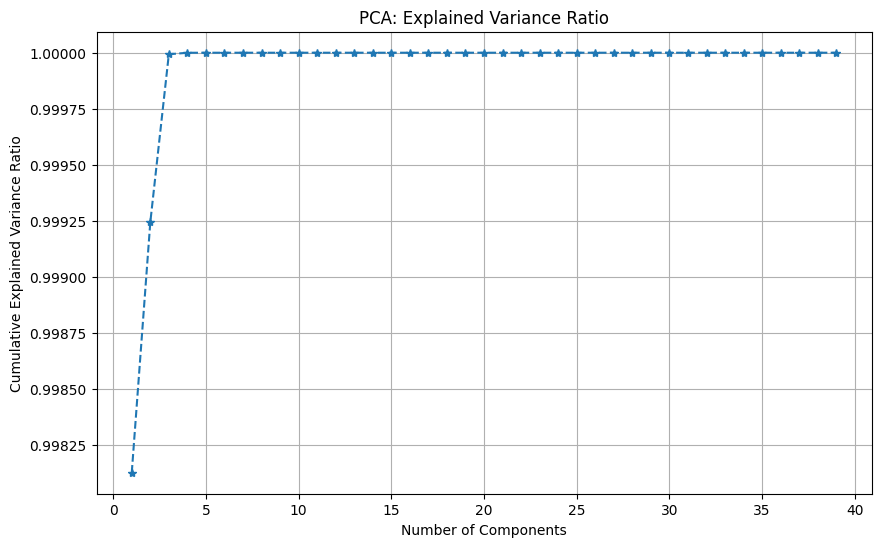

In [279]:
from sklearn.decomposition import PCA

# # Assuming 'X' contains your features
# pca = PCA(n_components= 23)
# pca.fit(X_train)

#Assuming 'X' contains your features
pca = PCA()
pca.fit(X_trainResampled)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_.cumsum(), marker='*', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA: Explained Variance Ratio')
plt.grid(True)
plt.show()

In [280]:
#apply the optimal n_components to a new pca.
#keeping it as point of inflection is causing certain models to underfit

components = 10

pca = PCA(n_components= components)

X_train_pca = pca.fit_transform(X_trainResampled)   #resampled and pca both done.
X_test_pca = pca.transform(X_test)
X_val_pca = pca.transform(X_val)

In [281]:
X_val_pca

array([[ 1.02948168e+04, -3.40489499e+00, -8.24407870e+01, ...,
        -3.08381277e-01, -6.33601646e-02,  2.79045644e-02],
       [-1.37521338e+03, -2.66041595e+00, -8.10565532e+01, ...,
        -9.11199413e-01, -1.37348990e-01, -3.16555715e-01],
       [-1.37521338e+03, -2.66041595e+00, -8.10565532e+01, ...,
        -9.11199413e-01, -1.37348990e-01, -3.16555715e-01],
       ...,
       [-1.37521338e+03, -2.66041595e+00, -8.10565532e+01, ...,
        -9.11199413e-01, -1.37348990e-01, -3.16555715e-01],
       [-1.37521338e+03, -2.66041593e+00, -8.10565524e+01, ...,
        -9.10937660e-01, -1.35803820e-01, -3.10615443e-01],
       [-1.37521322e+03, -3.70622016e+00, -8.09978308e+01, ...,
        -2.01543162e+00,  7.34140761e-02, -1.89099878e-01]])

In [282]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score,roc_curve
from sklearn.model_selection import cross_val_score


def model_eval(model,X_train, y_train, X_val, y_val, X_test, y_test):
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

    print(f"ROC AUC: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

    #calculate training accuracy
    trainPred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, trainPred)
    print(f"\nThe training accuracy of the model will be: {np.round(accuracy_score(y_train, trainPred), 3)*100}%\n")

    #calculate validation accuracy
    valPred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, valPred)
    print(f"The validation accuracy of the model will be: {np.round(accuracy_score(y_val, valPred), 3)*100}%\n")

    testPred = model.predict(X_test)

    model_name = type(model).__name__

    print(f"{model_name} testing report on unseen data")
    print(classification_report(y_test, testPred))
    print("The confusion matrix will be: \n")
    print(confusion_matrix(y_test, testPred))
    print(f"The ROC-AUC score on the testing data will be: {np.round(roc_auc_score(y_test, testPred), 3)}\n")


    fpr, tpr, thresholds = roc_curve(y_test, testPred)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    print(f"\nThe testing accuracy of the model on unseen data will be: {np.round(accuracy_score(y_test, testPred), 3)*100}%\n")

ROC AUC: 0.9905 (+/- 0.0009)


The training accuracy of the model will be: 98.7%

The validation accuracy of the model will be: 97.6%

LogisticRegression testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     59404
           1       0.94      0.99      0.96     14699

    accuracy                           0.99     74103
   macro avg       0.97      0.99      0.98     74103
weighted avg       0.99      0.99      0.99     74103

The confusion matrix will be: 

[[58445   959]
 [  134 14565]]
The ROC-AUC score on the testing data will be: 0.987


The testing accuracy of the model on unseen data will be: 98.5%



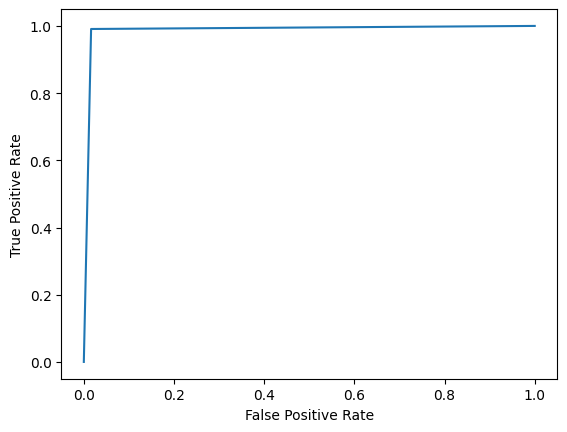

In [283]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression

# Calculate class weights for imbalance handling
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

# Initialize and train Logistic Regression model with class weights and L2 regularization
lrL2 = LogisticRegression(penalty='l2', C=1.0, class_weight=dict(enumerate(class_weights)), random_state=42, multi_class= "multinomial")
lrL2.fit(X_train_pca, y_trainResampled)

model_eval(lrL2, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)


ROC AUC: 0.9997 (+/- 0.0001)


The training accuracy of the model will be: 100.0%

The validation accuracy of the model will be: 99.9%

XGBClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59404
           1       1.00      1.00      1.00     14699

    accuracy                           1.00     74103
   macro avg       1.00      1.00      1.00     74103
weighted avg       1.00      1.00      1.00     74103

The confusion matrix will be: 

[[59388    16]
 [    9 14690]]
The ROC-AUC score on the testing data will be: 1.0


The testing accuracy of the model on unseen data will be: 100.0%



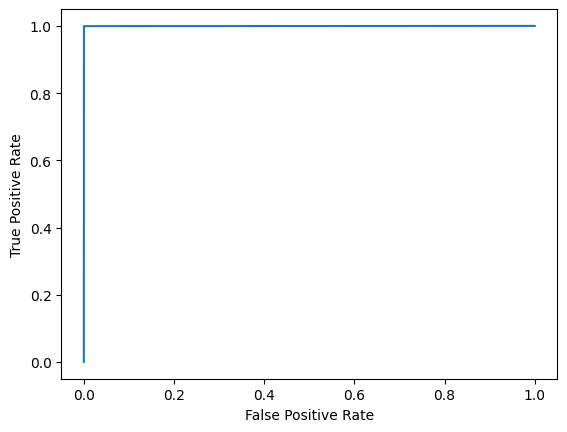

In [284]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:hinge", random_state=42)
xgb_model.fit(X_train_pca, y_trainResampled)

model_eval(xgb_model, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

ROC AUC: 0.9995 (+/- 0.0002)


The training accuracy of the model will be: 100.0%

The validation accuracy of the model will be: 99.8%

DecisionTreeClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59404
           1       1.00      1.00      1.00     14699

    accuracy                           1.00     74103
   macro avg       1.00      1.00      1.00     74103
weighted avg       1.00      1.00      1.00     74103

The confusion matrix will be: 

[[59367    37]
 [   24 14675]]
The ROC-AUC score on the testing data will be: 0.999


The testing accuracy of the model on unseen data will be: 99.9%



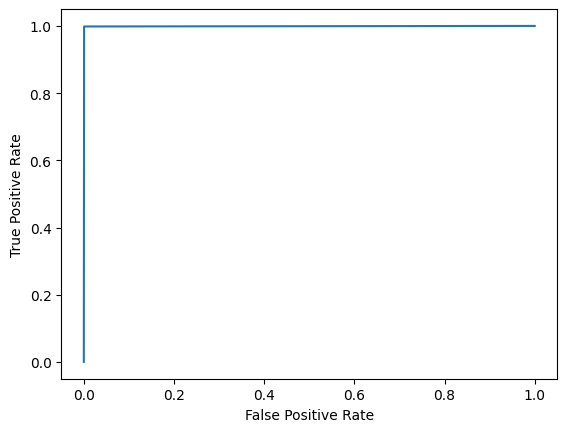

In [285]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train_pca, y_trainResampled)

model_eval(dtc, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

ROC AUC: 0.9779 (+/- 0.0006)


The training accuracy of the model will be: 95.39999999999999%

The validation accuracy of the model will be: 97.1%

BernoulliNB testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     59404
           1       0.88      0.98      0.93     14699

    accuracy                           0.97     74103
   macro avg       0.94      0.97      0.96     74103
weighted avg       0.97      0.97      0.97     74103

The confusion matrix will be: 

[[57480  1924]
 [  276 14423]]
The ROC-AUC score on the testing data will be: 0.974


The testing accuracy of the model on unseen data will be: 97.0%



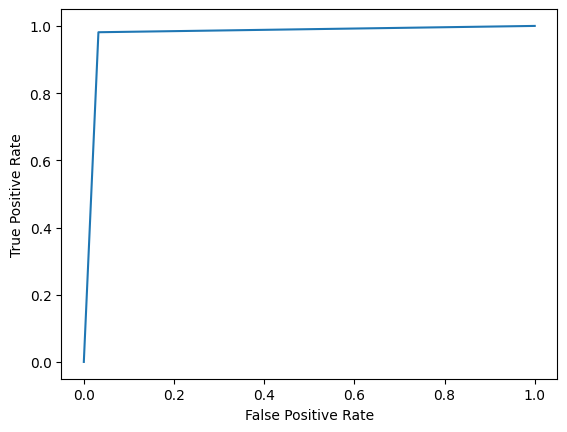

In [286]:
from sklearn.naive_bayes import BernoulliNB

# Train Gaussian Naive Baye Model
BNB_Classifier = BernoulliNB()
BNB_Classifier.fit(X_train_pca, y_trainResampled)

model_eval(BNB_Classifier, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

ROC AUC: 1.0000 (+/- 0.0000)


The training accuracy of the model will be: 100.0%

The validation accuracy of the model will be: 99.9%

RandomForestClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59404
           1       1.00      1.00      1.00     14699

    accuracy                           1.00     74103
   macro avg       1.00      1.00      1.00     74103
weighted avg       1.00      1.00      1.00     74103

The confusion matrix will be: 

[[59380    24]
 [    7 14692]]
The ROC-AUC score on the testing data will be: 1.0


The testing accuracy of the model on unseen data will be: 100.0%



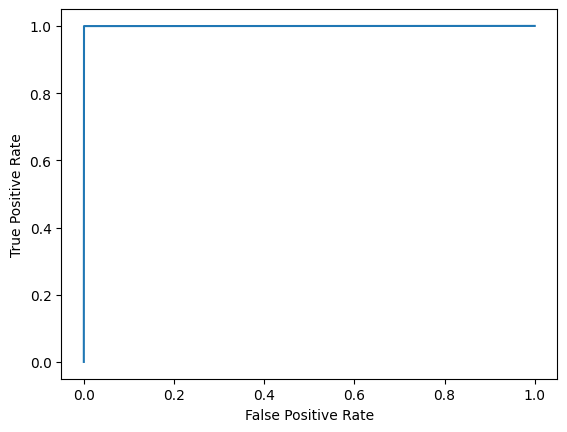

In [287]:
from sklearn.ensemble import RandomForestClassifier

rfcFinal = RandomForestClassifier(n_jobs= -1, n_estimators= 15, criterion= "entropy")
rfcFinal.fit(X_train_pca, y_trainResampled)

model_eval(rfcFinal, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

ROC AUC: 0.9965 (+/- 0.0002)


The training accuracy of the model will be: 98.7%

The validation accuracy of the model will be: 98.6%

LinearSVC testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     59404
           1       0.94      0.99      0.96     14699

    accuracy                           0.99     74103
   macro avg       0.97      0.99      0.98     74103
weighted avg       0.99      0.99      0.99     74103

The confusion matrix will be: 

[[58489   915]
 [  144 14555]]
The ROC-AUC score on the testing data will be: 0.987


The testing accuracy of the model on unseen data will be: 98.6%



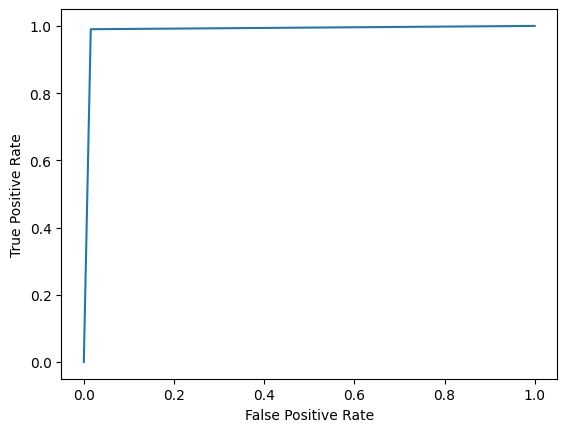

In [288]:
from sklearn.svm import LinearSVC

newSVM = LinearSVC()
newSVM.fit(X_train_pca, y_trainResampled)

model_eval(newSVM, X_train_pca, y_trainResampled, X_val_pca, y_val, X_test_pca, y_test)

# **Multi Class**

In [289]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

y = y.str.rstrip('.')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [290]:
X_train.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
133888,0,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,511,511,0.0,0.0,0.0,0.0,1.00,0.00,0.0,255,255,1.00,0.00,1.00,0.0,0.0,0.0,0.0,0.0
67704,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,220,10,1.0,1.0,0.0,0.0,0.05,0.06,0.0,255,10,0.04,0.07,0.00,0.0,1.0,1.0,0.0,0.0
391027,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,295,24,1.0,1.0,0.0,0.0,0.08,0.05,0.0,255,24,0.09,0.05,0.00,0.0,1.0,1.0,0.0,0.0
372089,0,tcp,http,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,1.0,1.0,1.00,0.00,0.0,8,8,1.00,0.00,0.12,0.0,0.0,0.0,1.0,1.0
460597,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,111,7,0.0,0.0,1.0,1.0,0.06,0.07,0.0,255,7,0.03,0.07,0.00,0.0,0.0,0.0,1.0,1.0


In [291]:
X_train.nunique()

,0
duration,2117
protocol_type,3
service,65
flag,11
src_bytes,3065
dst_bytes,9747
land,2
wrong_fragment,3
urgent,4
hot,22


In [292]:
#remove num_outbound_cmds as it has only 1 unique value, hence no real use for it.

X_train.drop(['num_outbound_cmds', "is_host_login"], axis=1, inplace=True)
X_test.drop(['num_outbound_cmds', "is_host_login"], axis=1, inplace=True)

In [293]:
X_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,395216.000000,3.952160e+05,3.952160e+05,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000,395216.000000
mean,47.440458,3.376421e+03,8.490896e+02,0.000053,0.006548,0.000018,0.034318,0.000170,0.148547,0.009494,0.000106,0.000035,0.010652,0.001070,0.000101,0.001045,0.001392,332.071386,292.618158,0.177122,0.177019,0.057312,0.057620,0.791121,0.021003,0.029011,232.466122,188.596540,0.753511,0.030853,0.601189,0.006671,0.177174,0.176839,0.058029,0.057290
std,698.194390,1.104474e+06,3.133821e+04,0.007289,0.135787,0.006161,0.779550,0.016758,0.355641,1.597168,0.010308,0.007793,1.786916,0.102158,0.010060,0.036846,0.037279,213.188312,246.373954,0.381076,0.381361,0.231392,0.231962,0.388493,0.082147,0.142360,64.753992,106.071653,0.410917,0.108955,0.481466,0.042165,0.380942,0.381258,0.230416,0.229915
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,117.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,45.000000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,510.000000,510.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,511.000000,511.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.153771e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,1.000000,2.000000,993.000000,28.000000,1.000000,8.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [294]:
# Convert categorical features using one-hot encoding
categorical_cols = ['protocol_type', 'service', 'flag']  # Add other categorical columns if needed

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Calculate correlation on the encoded DataFrame
correlation_matrix = X_train_encoded.corr()

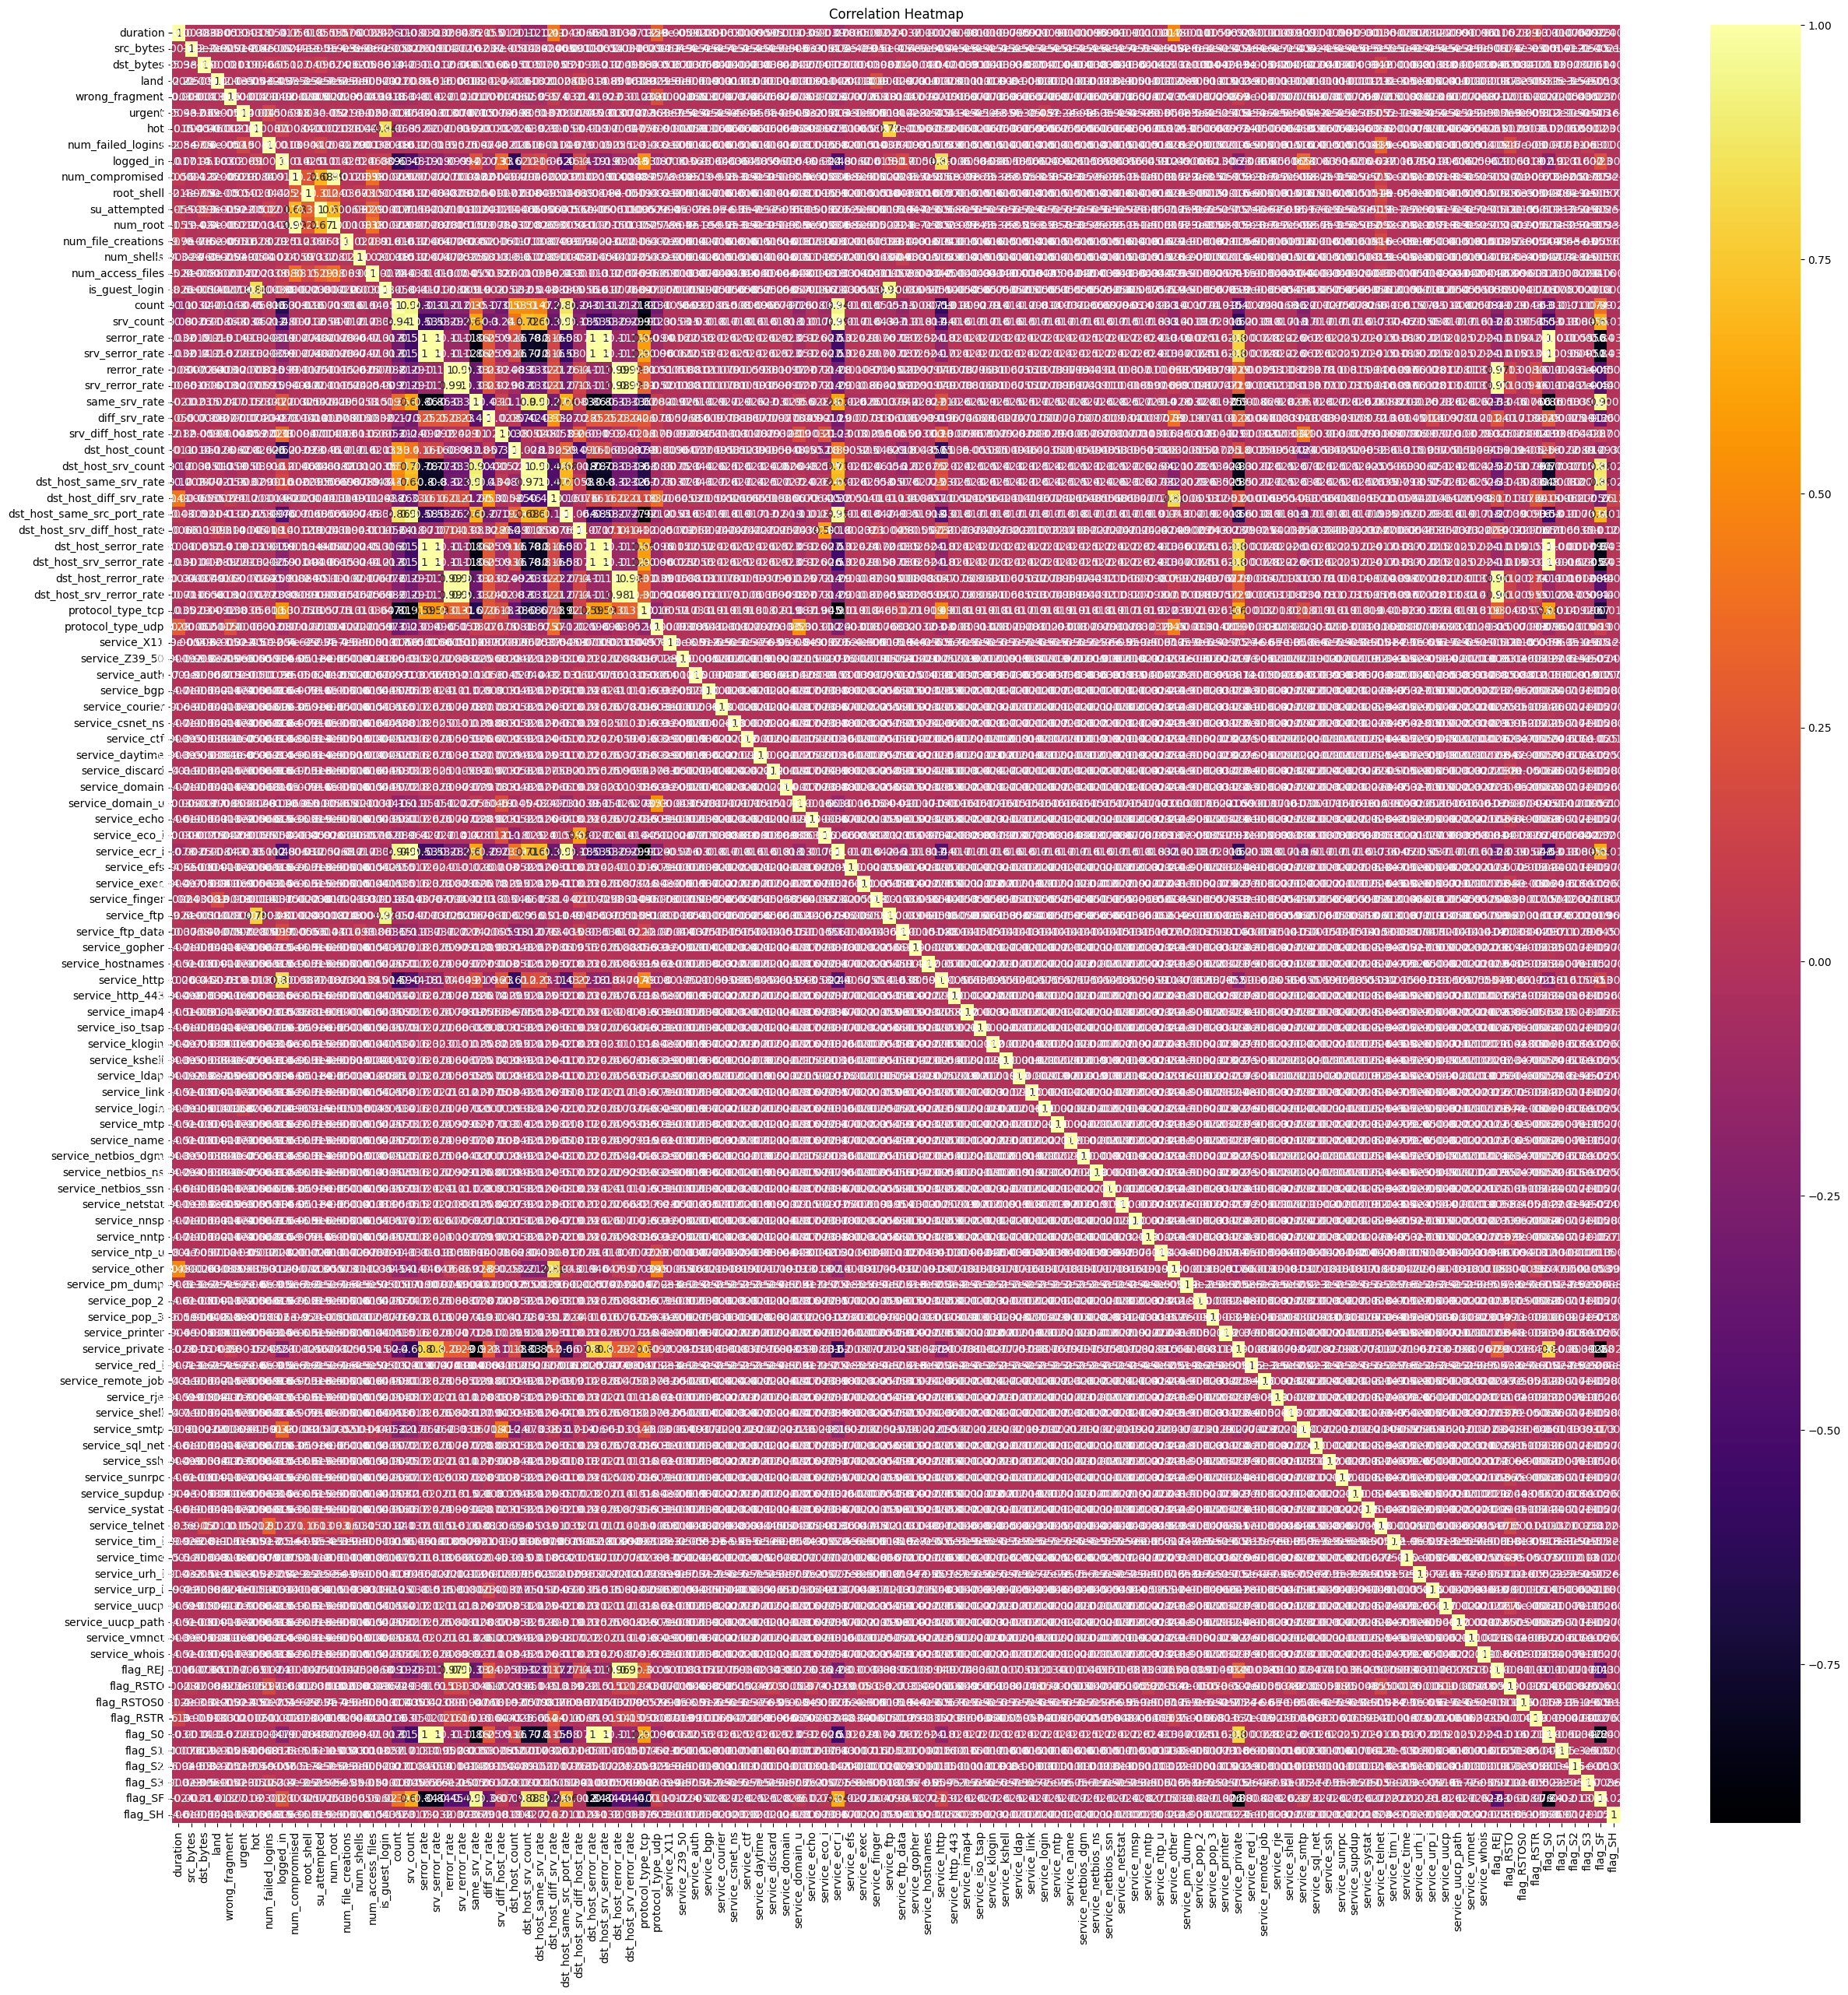

In [295]:
plt.figure(figsize=(30, 30))
sns.heatmap(correlation_matrix, annot=True, cmap='inferno')
plt.title('Correlation Heatmap')
plt.show()

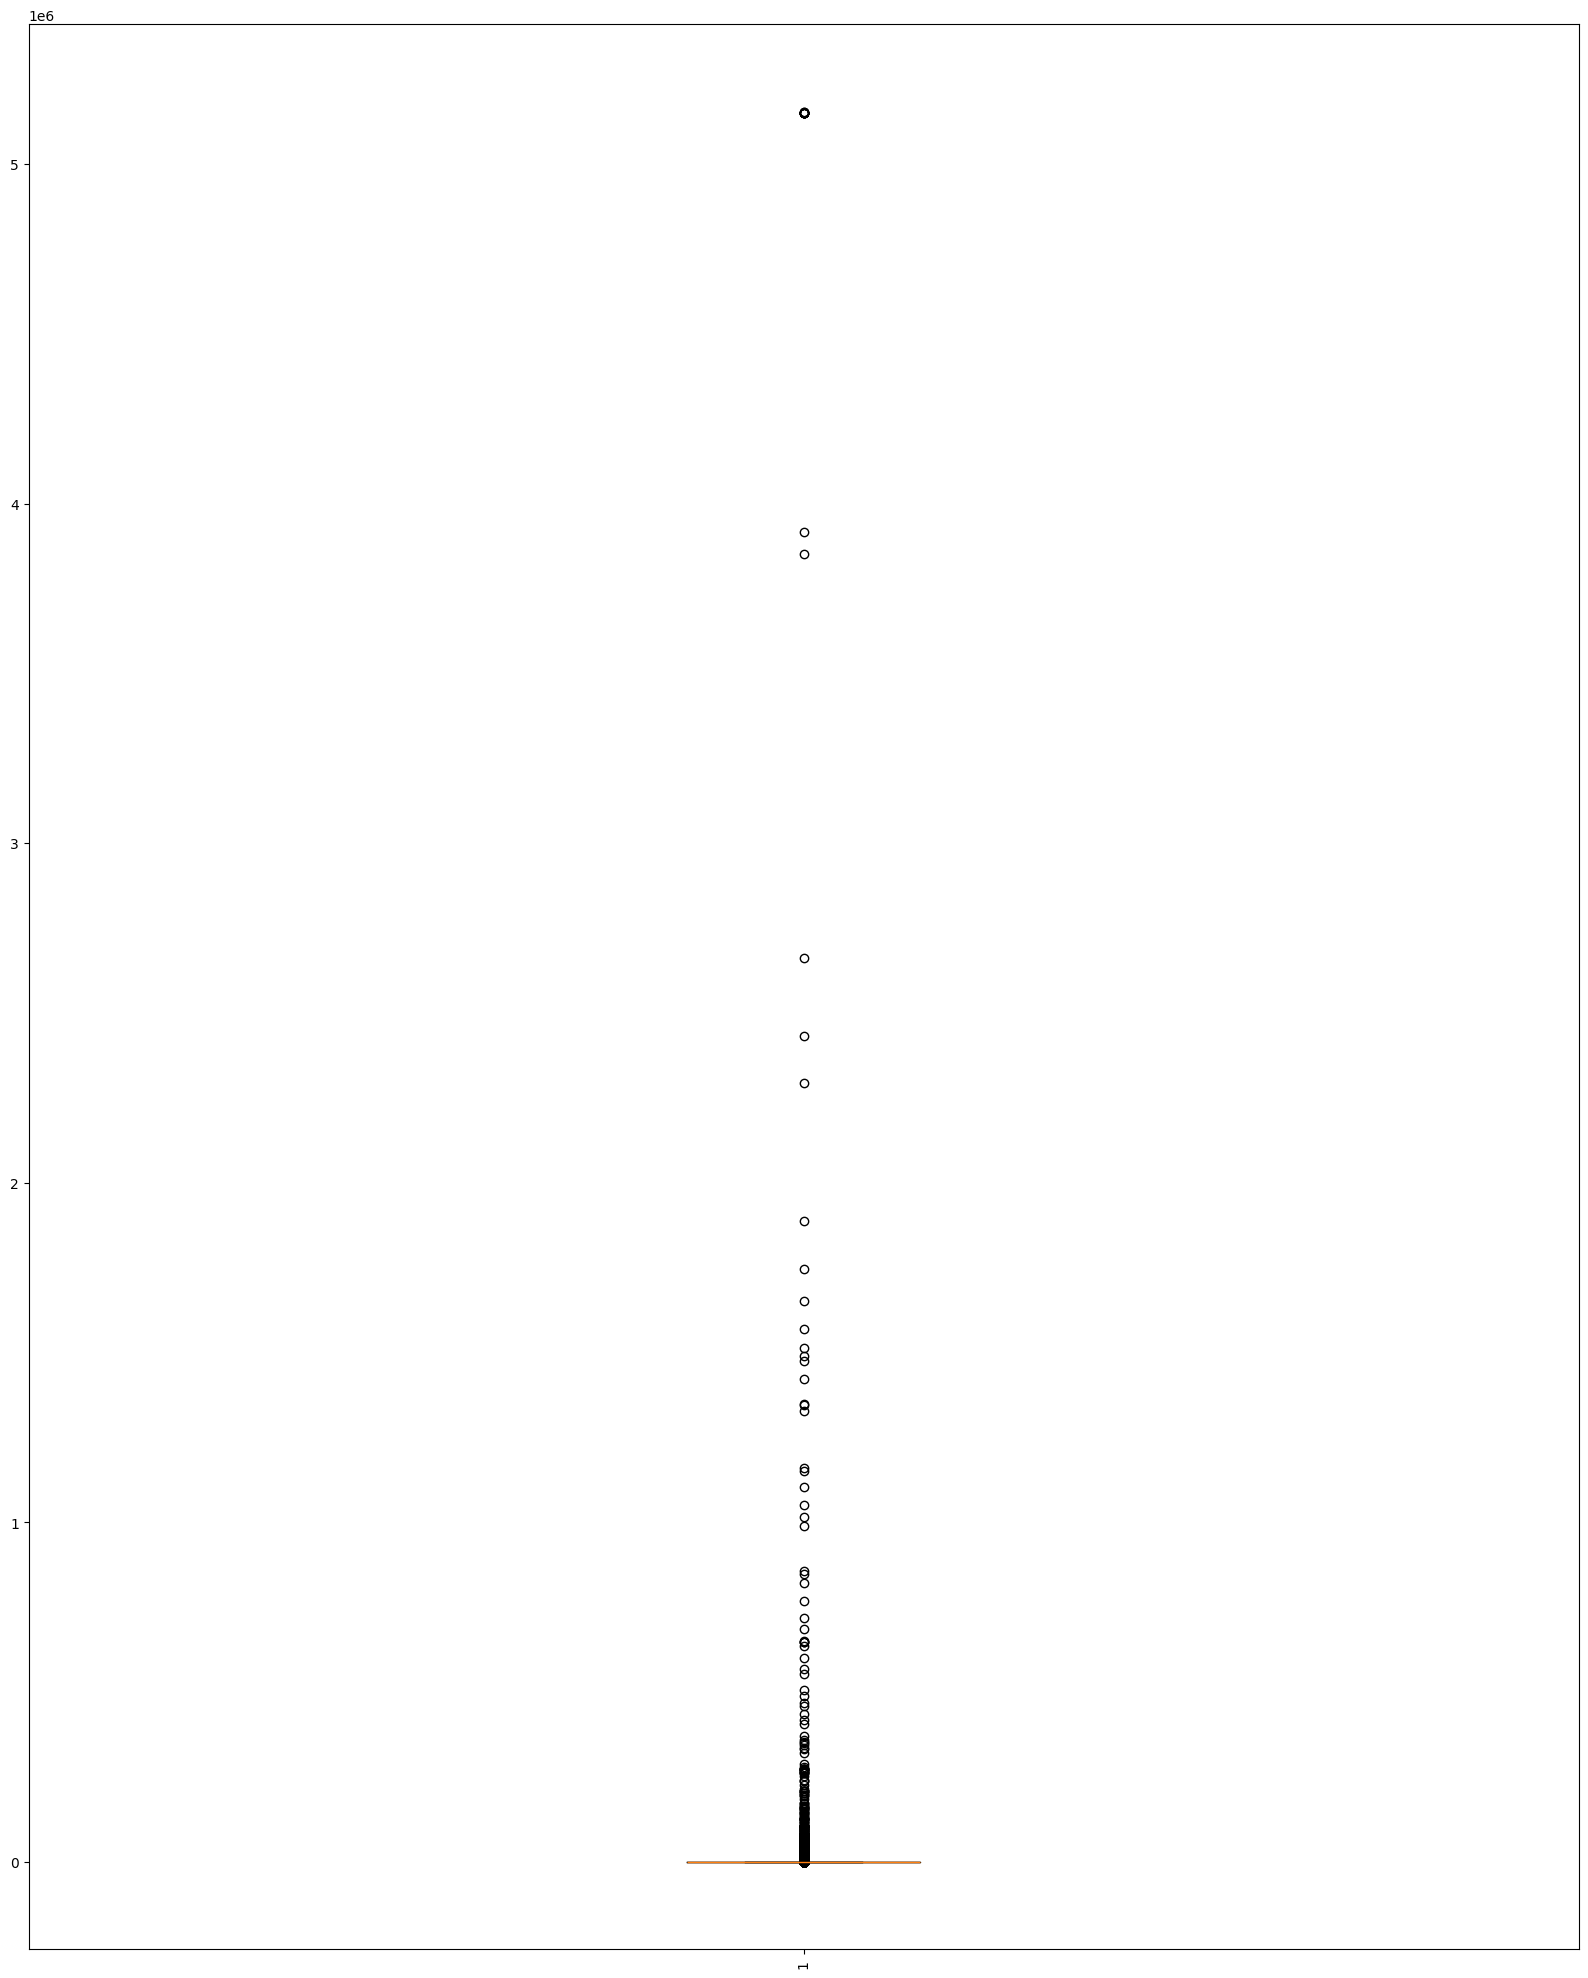

In [296]:
plt.figure(figsize= (20, 25))
plt.boxplot(X_train["dst_bytes"])
plt.xticks(rotation=90)  # Rotates x-axis labels for better visibility if needed
plt.show()

<Axes: xlabel='dst_bytes', ylabel='num_file_creations'>

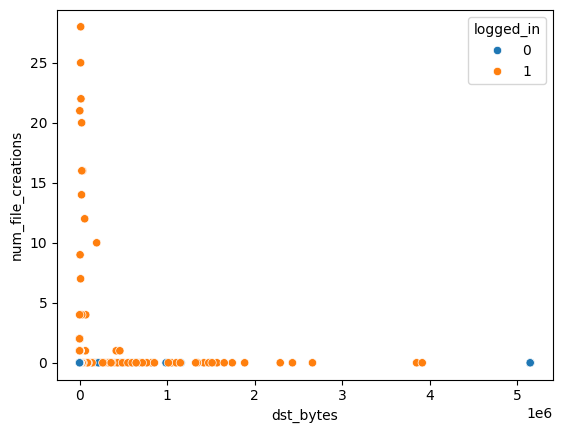

In [297]:
sns.scatterplot(data= X_train, x= "dst_bytes", y="num_file_creations", hue= "logged_in")

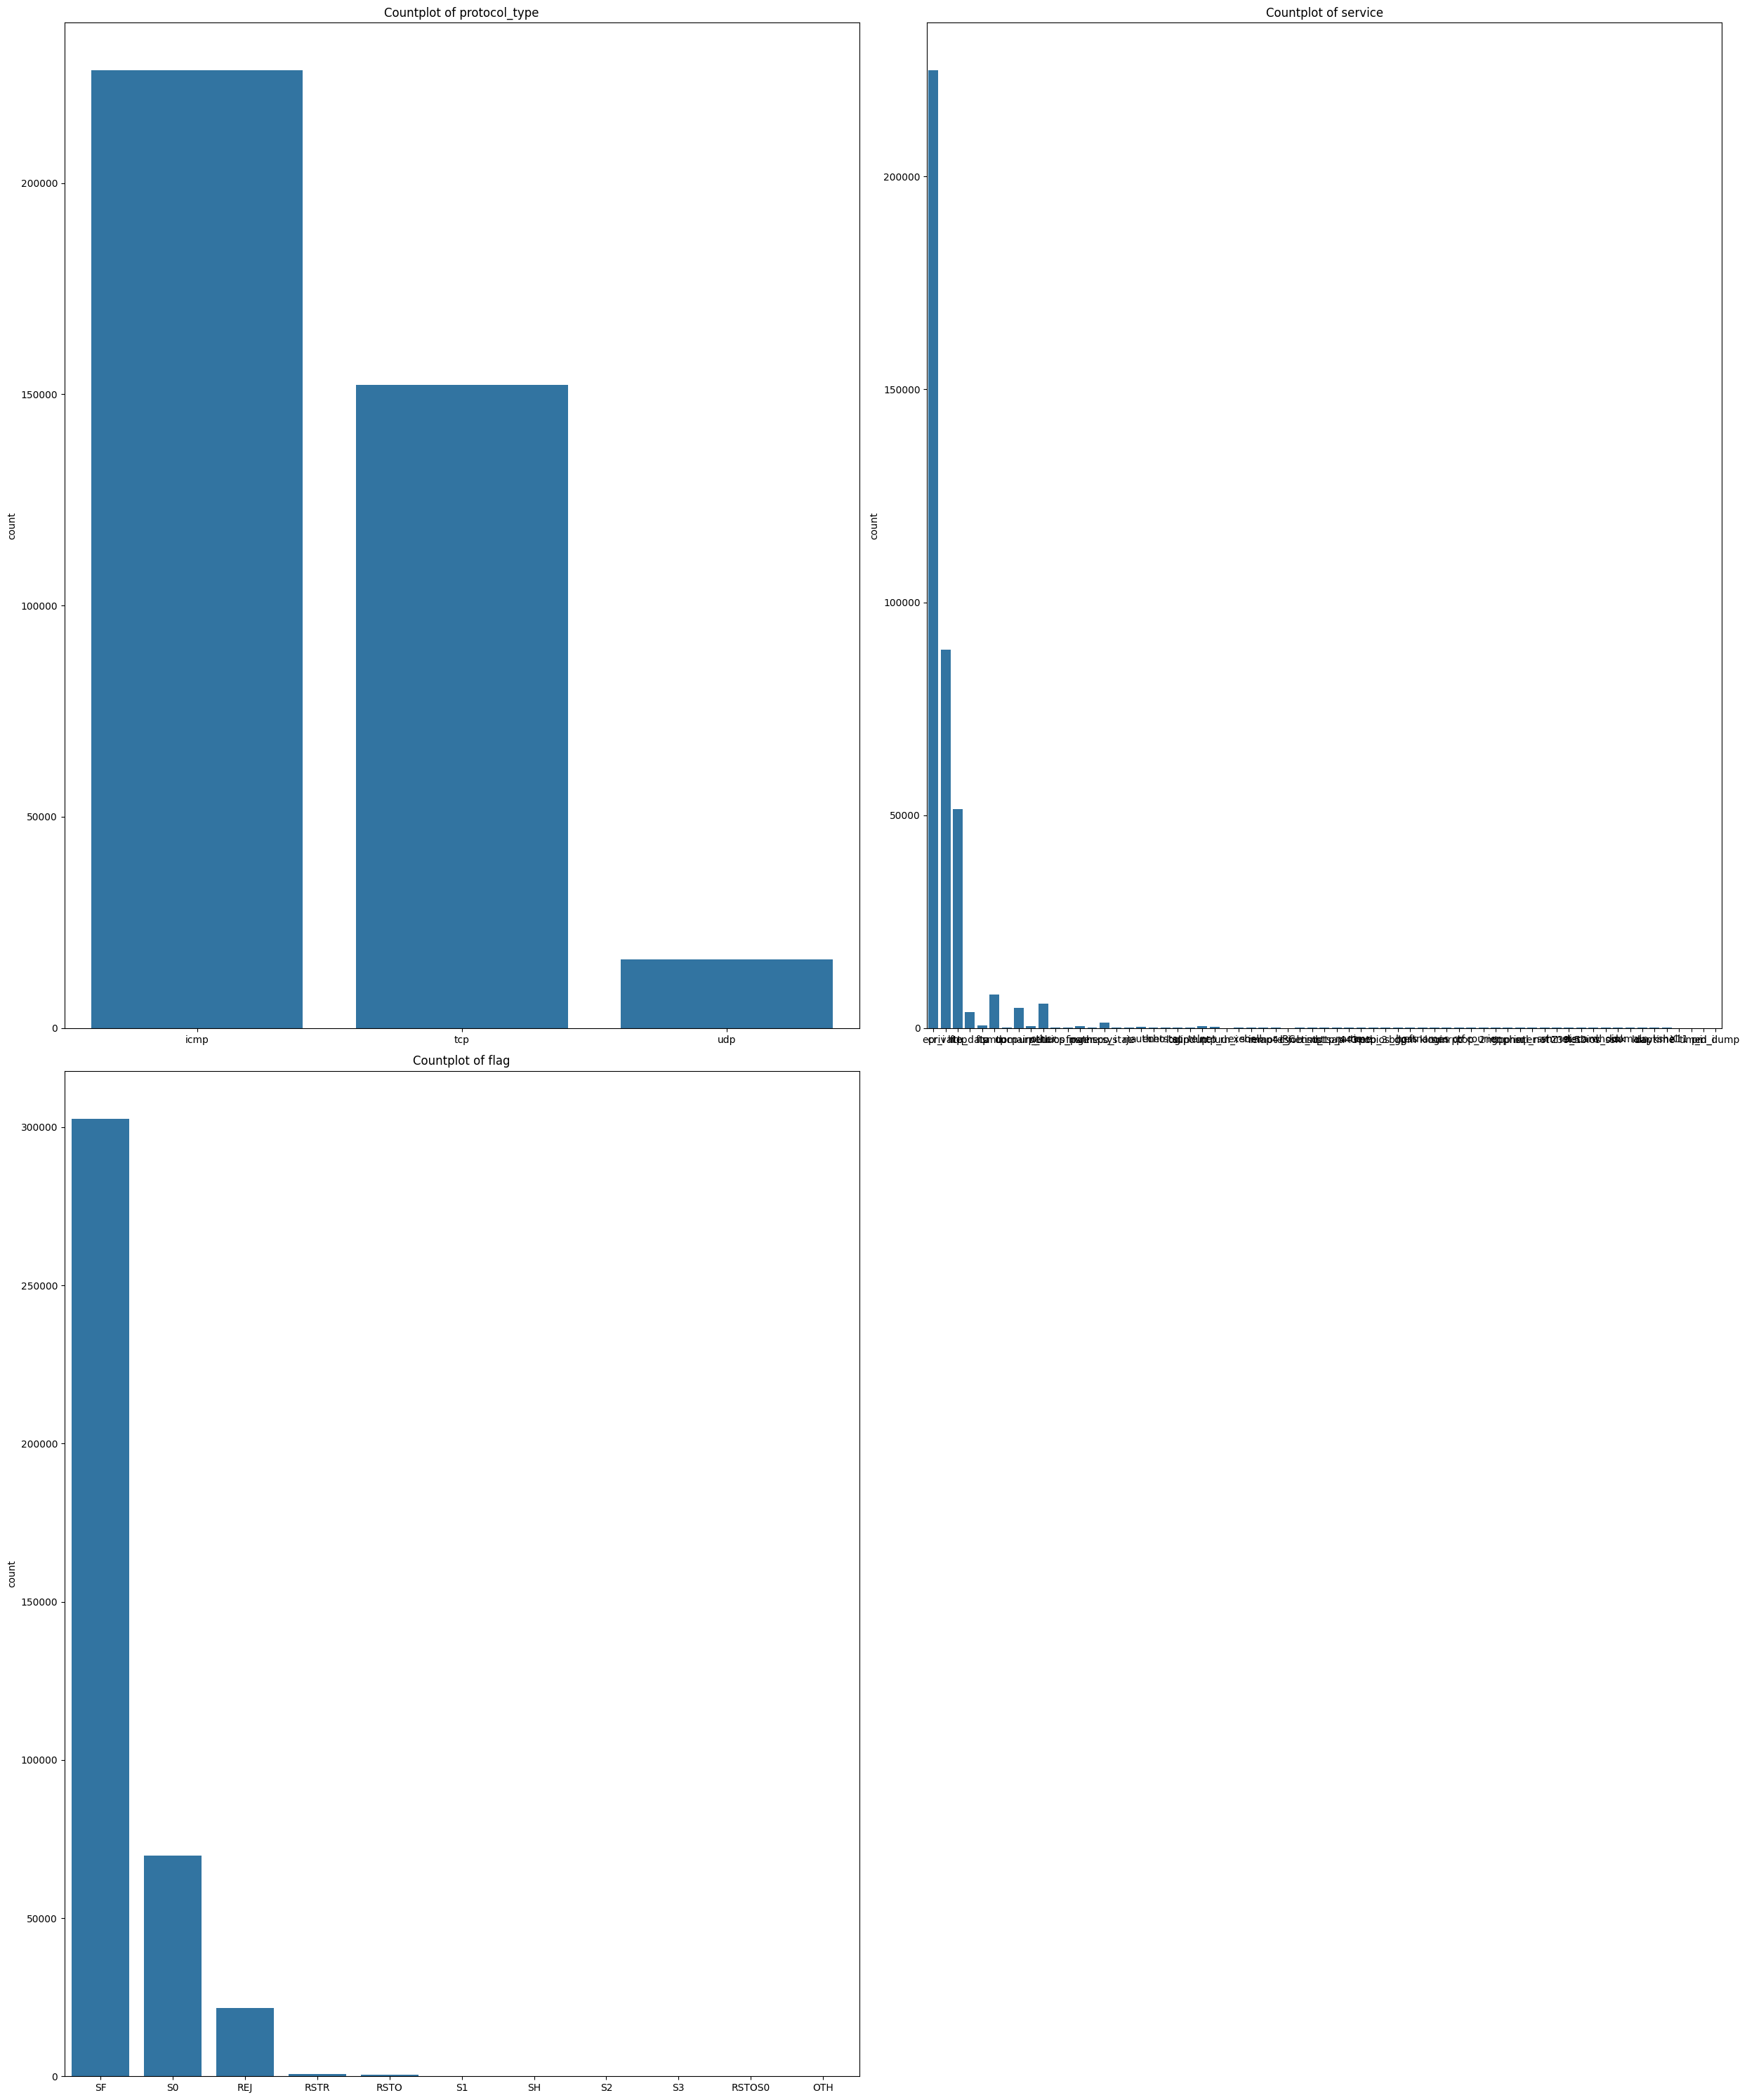

In [298]:
columns_to_visualize = ["protocol_type", "service", "flag"]

# Set up the plot grid
num_plots = len(columns_to_visualize)
num_cols = 2  # Number of columns in the plot grid
num_rows = (num_plots + 1) // num_cols

plt.figure(figsize=(25, 30))

# Create countplots for each specified column
for i, column in enumerate(columns_to_visualize, start=1):
    plt.subplot(num_rows, num_cols, i)
    sns.countplot(data=X_train, x=column)
    plt.title(f'Countplot of {column}')
    plt.xlabel('')  # Optionally remove x-axis label for better visualization

plt.tight_layout()
plt.show()

<Axes: xlabel='duration', ylabel='Count'>

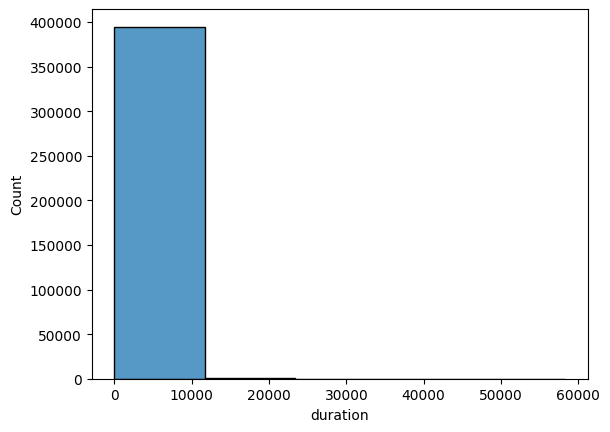

In [299]:
sns.histplot(X_train, x= "duration", bins= 5)

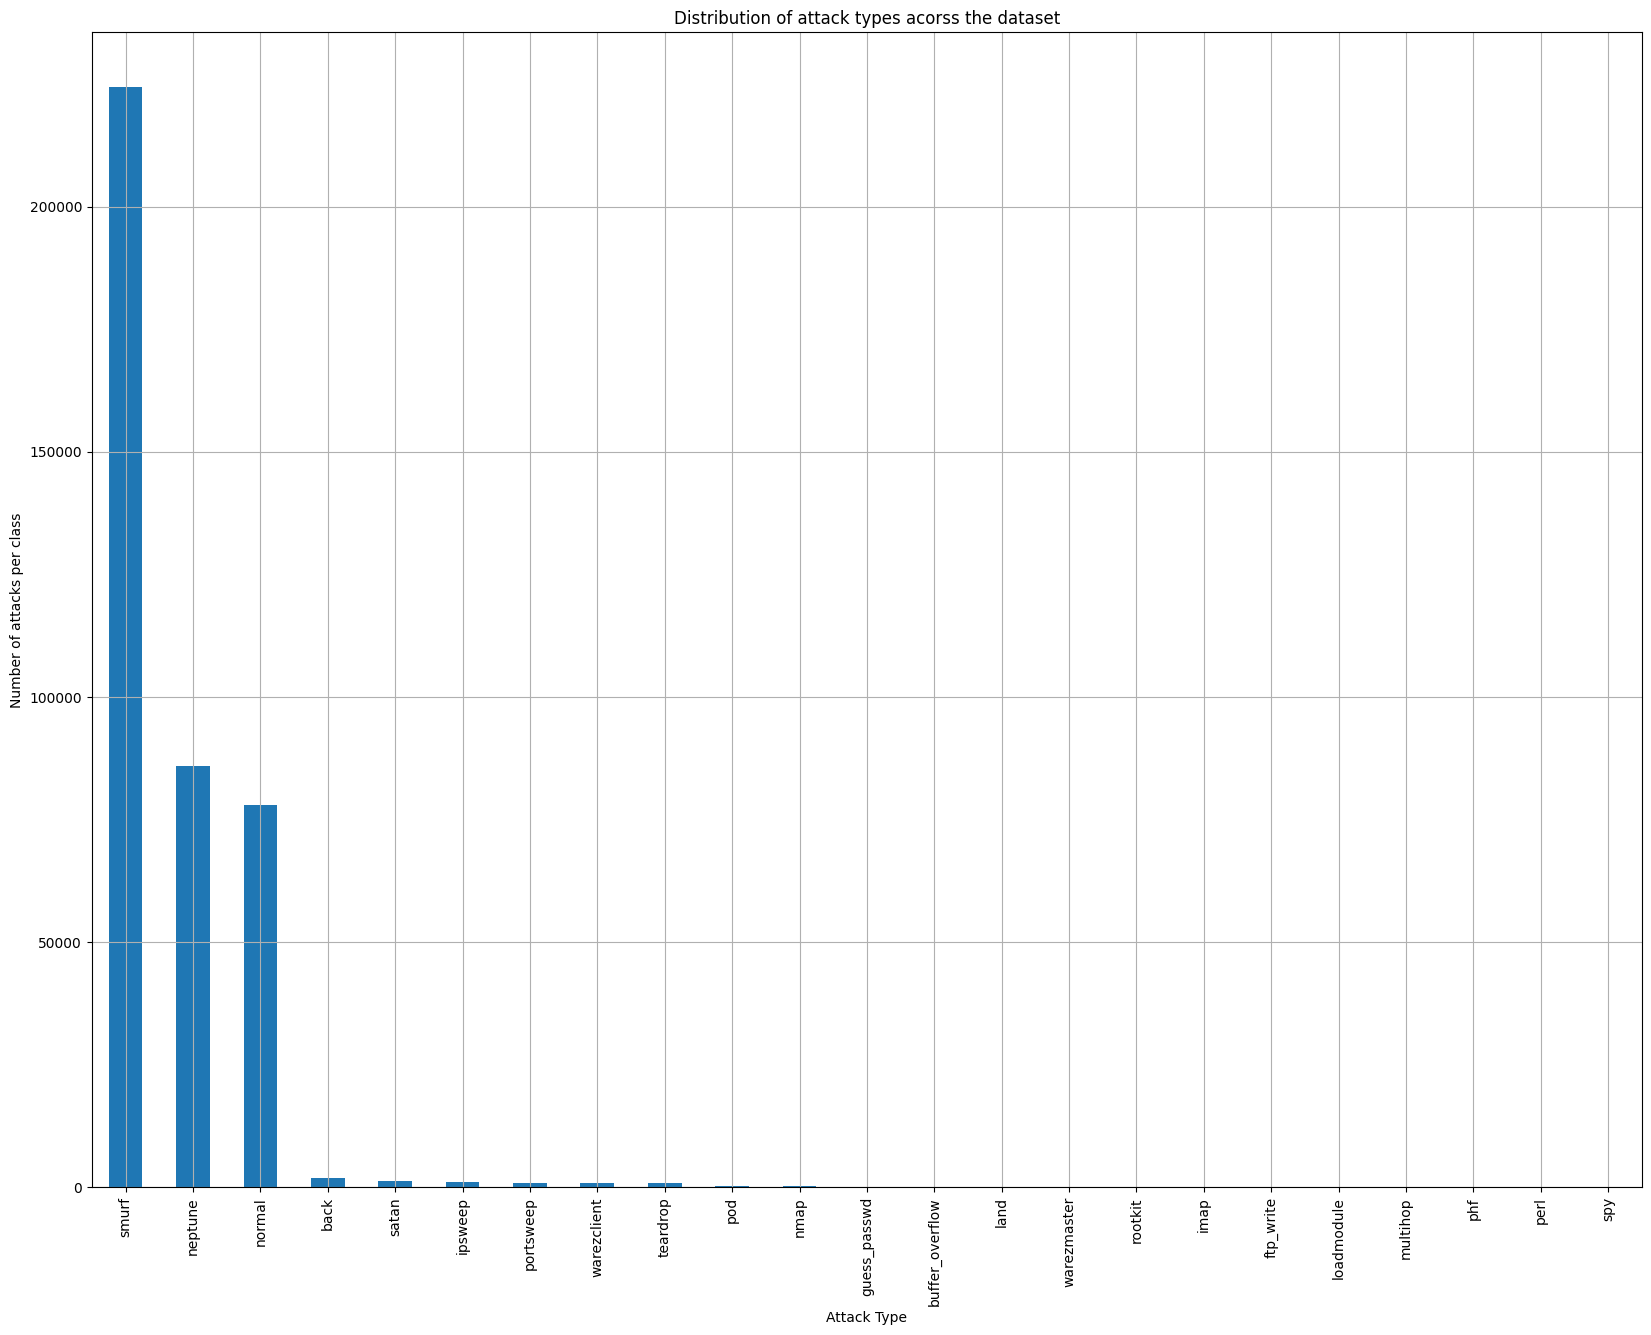

In [300]:
plt.figure(figsize=(20,15))
class_distribution = y_train.value_counts()
class_distribution.plot(kind= "bar")
plt.xlabel('Attack Type')
plt.ylabel('Number of attacks per class')
plt.title('Distribution of attack types acorss the dataset')
plt.grid()
plt.show()

In [301]:
attackTypesCount = y_train.value_counts()
attackTypesCount.sum()

395216

In [302]:
attackTypesCount.index

Index(['smurf', 'neptune', 'normal', 'back', 'satan', 'ipsweep', 'portsweep',
       'warezclient', 'teardrop', 'pod', 'nmap', 'guess_passwd',
       'buffer_overflow', 'land', 'warezmaster', 'rootkit', 'imap',
       'ftp_write', 'loadmodule', 'multihop', 'phf', 'perl', 'spy'],
      dtype='object', name='attack_type')

In [303]:
for i in range(len(attackTypesCount)):
  print(f"The class {attackTypesCount.index[i].capitalize()} has {attackTypesCount[i]} data points ({np.round((attackTypesCount[i]/attackTypesCount.sum()*100), 3)}%)")

The class Smurf has 224388 data points (56.776%)
The class Neptune has 85907 data points (21.737%)
The class Normal has 77925 data points (19.717%)
The class Back has 1768 data points (0.447%)
The class Satan has 1285 data points (0.325%)
The class Ipsweep has 982 data points (0.248%)
The class Portsweep has 804 data points (0.203%)
The class Warezclient has 802 data points (0.203%)
The class Teardrop has 794 data points (0.201%)
The class Pod has 226 data points (0.057%)
The class Nmap has 186 data points (0.047%)
The class Guess_passwd has 45 data points (0.011%)
The class Buffer_overflow has 21 data points (0.005%)
The class Land has 20 data points (0.005%)
The class Warezmaster has 16 data points (0.004%)
The class Rootkit has 10 data points (0.003%)
The class Imap has 9 data points (0.002%)
The class Ftp_write has 7 data points (0.002%)
The class Loadmodule has 7 data points (0.002%)
The class Multihop has 6 data points (0.002%)
The class Phf has 4 data points (0.001%)
The class P

In [304]:
numericDataX_train = X_train.select_dtypes(include=["int64", "float64"])
numericDataX_test = X_test.select_dtypes(include=["int64", "float64"])

numericCols = X_train.select_dtypes(include=["int64", "float64"]).columns
numericCols

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'],
      dtype='object')

In [305]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_trainScaled = scaler.fit_transform(numericDataX_train)
X_testScaled = scaler.fit_transform(numericDataX_test)

In [306]:
X_trainScaled

array([[-6.79474349e-02, -2.12266082e-03, -2.70944236e-02, ...,
        -4.63830966e-01, -2.51844916e-01, -2.49177664e-01],
       [-6.79474349e-02, -3.05704317e-03, -2.70944236e-02, ...,
         2.15907035e+00, -2.51844916e-01, -2.49177664e-01],
       [-6.79474349e-02, -3.05704317e-03, -2.70944236e-02, ...,
         2.15907035e+00, -2.51844916e-01, -2.49177664e-01],
       ...,
       [-6.79474349e-02, -2.12266082e-03, -2.70944236e-02, ...,
        -4.63830966e-01, -2.51844916e-01, -2.49177664e-01],
       [ 1.30244115e+01, -2.92394801e-03, -2.37438768e-02, ...,
        -4.63830966e-01, -2.51844916e-01, -2.49177664e-01],
       [-6.79474349e-02, -3.05704317e-03, -2.70944236e-02, ...,
         2.15907035e+00, -2.51844916e-01, -2.49177664e-01]])

In [307]:
X_trainScaled = pd.DataFrame(data= X_trainScaled, columns= numericCols)
X_testScaled = pd.DataFrame(data= X_testScaled, columns= numericCols)

In [308]:
X_trainScaled.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05,3.952160e+05
mean,-3.901355e-18,7.461116e-19,-1.510202e-18,-2.022592e-18,7.398191e-18,-1.114673e-18,-1.119167e-17,1.707966e-19,1.778083e-17,2.251819e-18,-6.544208e-18,-3.564256e-18,-1.905731e-18,2.494530e-18,4.485659e-18,6.652079e-18,1.636052e-17,7.497073e-18,1.176519e-16,-8.680064e-17,-1.797859e-19,-6.364422e-18,1.233601e-16,1.025499e-16,-6.481283e-18,2.540375e-17,4.917145e-17,1.350552e-16,1.120642e-15,-3.568751e-17,2.673776e-16,9.852269e-18,2.905341e-17,-2.588198e-16,-8.714224e-17,-9.528654e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-6.794743e-02,-3.057043e-03,-2.709442e-02,-7.289604e-03,-4.822487e-02,-2.874994e-03,-4.402281e-02,-1.011622e-02,-4.176870e-01,-5.943991e-03,-1.030933e-02,-4.545793e-03,-5.961340e-03,-1.047695e-02,-1.006085e-02,-2.836092e-02,-3.733073e-02,-1.557645e+00,-1.187701e+00,-4.647938e-01,-4.641776e-01,-2.476830e-01,-2.484045e-01,-2.036384e+00,-2.556747e-01,-2.037867e-01,-3.589994e+00,-1.778013e+00,-1.833732e+00,-2.831680e-01,-1.248665e+00,-1.582201e-01,-4.650939e-01,-4.638310e-01,-2.518449e-01,-2.491777e-01
25%,-6.794743e-02,-3.017205e-03,-2.709442e-02,-7.289604e-03,-4.822487e-02,-2.874994e-03,-4.402281e-02,-1.011622e-02,-4.176870e-01,-5.943991e-03,-1.030933e-02,-4.545793e-03,-5.961340e-03,-1.047695e-02,-1.006085e-02,-2.836092e-02,-3.733073e-02,-1.008834e+00,-1.147112e+00,-4.647938e-01,-4.641776e-01,-2.476830e-01,-2.484045e-01,5.376662e-01,-2.556747e-01,-2.037867e-01,3.479925e-01,-1.353771e+00,-8.602986e-01,-2.831680e-01,-1.248665e+00,-1.582201e-01,-4.650939e-01,-4.638310e-01,-2.518449e-01,-2.491777e-01
50%,-6.794743e-02,-2.586230e-03,-2.709442e-02,-7.289604e-03,-4.822487e-02,-2.874994e-03,-4.402281e-02,-1.011622e-02,-4.176870e-01,-5.943991e-03,-1.030933e-02,-4.545793e-03,-5.961340e-03,-1.047695e-02,-1.006085e-02,-2.836092e-02,-3.733073e-02,8.346088e-01,8.823259e-01,-4.647938e-01,-4.641776e-01,-2.476830e-01,-2.484045e-01,5.376662e-01,-2.556747e-01,-2.037867e-01,3.479925e-01,6.260254e-01,5.998519e-01,-2.831680e-01,8.283260e-01,-1.582201e-01,-4.650939e-01,-4.638310e-01,-2.518449e-01,-2.491777e-01
75%,-6.794743e-02,-2.122661e-03,-2.709442e-02,-7.289604e-03,-4.822487e-02,-2.874994e-03,-4.402281e-02,-1.011622e-02,-4.176870e-01,-5.943991e-03,-1.030933e-02,-4.545793e-03,-5.961340e-03,-1.047695e-02,-1.006085e-02,-2.836092e-02,-3.733073e-02,8.392995e-01,8.863848e-01,-4.647938e-01,-4.641776e-01,-2.476830e-01,-2.484045e-01,5.376662e-01,-2.556747e-01,-2.037867e-01,3.479925e-01,6.260254e-01,5.998519e-01,8.395572e-02,8.283260e-01,-1.582201e-01,-4.650939e-01,-4.638310e-01,-2.518449e-01,-2.491777e-01
max

In [309]:
y_train.value_counts()

,count
attack_type,
smurf,224388
neptune,85907
normal,77925
back,1768
satan,1285
ipsweep,982
portsweep,804
warezclient,802
teardrop,794


In [310]:
class_mapping = {
    'back': 'DOS', 'buffer_overflow': 'U2R', 'ftp_write': 'R2L', 'guess_passwd': 'R2L',
    'imap': 'R2L', 'ipsweep': 'PROBE', 'land': 'DOS', 'loadmodule': 'U2R', 'multihop': 'R2L',
    'neptune': 'DOS', 'nmap': 'PROBE', 'perl': 'U2R', 'phf': 'R2L', 'pod': 'DOS',
    'portsweep': 'PROBE', 'rootkit': 'U2R', 'satan': 'PROBE', 'smurf': 'DOS',
    'spy': 'R2L', 'teardrop': 'DOS', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'normal': 'NORMAL'
}

# Map the original classes to the smaller classes using the mapping dictionary
y_train = y_train.map(class_mapping)

y_train.value_counts()

,count
attack_type,
DOS,313103
NORMAL,77925
PROBE,3257
R2L,891
U2R,40


In [311]:
y_test = y_test.map(class_mapping)

y_test.value_counts()

,count
attack_type,
DOS,78355
NORMAL,19353
PROBE,850
R2L,235
U2R,12


In [312]:
X_trainStrings = X_train.select_dtypes(include= 'object')
X_testStrings = X_test.select_dtypes(include= 'object')

stringCols = X_train.select_dtypes(include= 'object').columns
stringCols

Index(['protocol_type', 'service', 'flag'], dtype='object')

In [313]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

X_trainEncoded = X_trainStrings.apply(encoder.fit_transform)
X_testEncoded = X_testStrings.apply(encoder.fit_transform)

In [314]:
X_train = pd.concat([X_trainScaled.reset_index(drop=True), X_trainEncoded.reset_index(drop=True)], axis=1)

In [315]:
X_train

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag
0,-0.067947,-0.002123,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,0.839299,0.886385,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,-0.203787,0.347993,0.626025,0.599852,-0.283168,0.828326,-0.15822,-0.465094,-0.463831,-0.251845,-0.249178,0,14,9
1,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-0.525693,-1.147112,2.159358,2.158010,-0.247683,-0.248405,-1.907682,0.474723,-0.203787,0.347993,-1.683737,-1.736389,0.359299,-1.248665,-0.15822,2.159981,2.159070,-0.251845,-0.249178,1,45,5
2,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-0.173891,-1.090288,2.159358,2.158010,-0.247683,-0.248405,-1.830460,0.352990,-0.203787,0.347993,-1.551751,-1.614710,0.175737,-1.248665,-0.15822,2.159981,2.159070,-0.251845,-0.249178,1,45,5
3,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.552955,-1.183642,-0.464794,-0.464178,4.073993,4.062648,0.537666,-0.255675,-0.203787,-3.466449,-1.702592,0.599852,-0.283168,-0.999426,-0.15822,-0.465094,-0.463831,4.088139,4.100256,1,22,1
4,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.036978,-1.159289,-0.464794,-0.464178,4.073993,4.062648,-1.881941,0.596456,-0.203787,0.347993,-1.712020,-1.760725,0.359299,-1.248665,-0.15822,-0.465094,-0.463831,4.088139,4.100256,1,45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395211,-0.067947,-0.002123,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,0.839299,0.886385,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,-0.203787,0.347993,0.626025,0.599852,-0.283168,0.828326,-0.15822,-0.465094,-0.463831,-0.251845,-0.249178,0,14,9
395212,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.065123,-1.167406,2.159358,2.158010,-0.247683,-0.248405,-1.907682,0.596456,-0.203787,0.347993,-1.702592,-1.760725,0.267518,-1.248665,-0.15822,2.159981,2.159070,-0.251845,-0.249178,1,45,5
395213,-0.067947,-0.002123,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,0.839299,0.886385,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,-0.203787,0.347993,0.626025,0.599852,-0.283168,0.828326,-0.15822,-0.465094,-0.463831,-0.251845,-0.249178,0,14,9
395214,13.024412,-0.002924,-0.023744,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.552955,-1.183642,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,-0.203787,0.347993,-1.749730,-1.809396,3.479850,0.496007,-0.15822,-0.465094,-0.463831,-0.251845,-0.249178,2,40,9


In [316]:
X_test = pd.concat([X_testScaled.reset_index(drop=True), X_testEncoded.reset_index(drop=True)], axis=1)

In [317]:
X_test

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag
0,-0.06732,-0.010079,-0.024194,-0.003181,-0.045652,0.0,-0.044586,-0.008999,-0.415208,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,0.835082,0.881458,-0.461270,-0.460889,-0.249068,-0.249537,0.534271,-0.253526,-0.203019,0.347864,0.623687,0.597574,-0.281700,0.821946,-0.160273,-0.461710,-0.460686,-0.252817,-0.250607,0,14,9
1,-0.06732,-0.010079,-0.024194,-0.003181,-0.045652,0.0,-0.044586,-0.008999,-0.415208,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,0.835082,0.881458,-0.461270,-0.460889,-0.249068,-0.249537,0.534271,-0.253526,-0.203019,0.347864,0.623687,0.597574,-0.281700,0.821946,-0.160273,-0.461710,-0.460686,-0.252817,-0.250607,0,14,9
2,-0.06732,-0.010079,-0.024194,-0.003181,-0.045652,0.0,-0.044586,-0.008999,-0.415208,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,0.835082,0.881458,-0.461270,-0.460889,-0.249068,-0.249537,0.534271,-0.253526,-0.203019,0.347864,0.623687,0.597574,-0.281700,0.821946,-0.160273,-0.461710,-0.460686,-0.252817,-0.250607,0,14,9
3,-0.06732,-0.021808,0.114352,-0.003181,-0.045652,0.0,-0.044586,-0.008999,2.408430,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,-1.536015,-1.170430,-0.461270,-0.460889,-0.249068,-0.249537,0.534271,-0.253526,-0.203019,-2.031951,0.623687,0.597574,-0.281700,-1.237683,0.315855,-0.461710,-0.460686,-0.252817,-0.250607,1,22,9
4,-0.06732,-0.027698,-0.024194,-0.003181,-0.045652,0.0,-0.044586,-0.008999,-0.415208,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,-0.343424,-1.186683,2.175356,2.173257,-0.249068,-0.249537,-2.024085,0.474290,-0.203019,0.347864,-1.765020,-1.815681,0.351979,-1.258487,-0.160273,2.175495,2.173948,-0.252817,-0.250607,1,44,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98800,-0.06732,-0.027698,-0.024194,-0.003181,-0.045652,0.0,-0.044586,-0.008999,-0.415208,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,-0.963195,-1.150114,2.175356,2.173257,-0.249068,-0.249537,-1.817349,0.352988,-0.203019,0.347864,-1.717813,-1.766928,0.351979,-1.258487,-0.160273,2.175495,2.173948,-0.252817,-0.250607,1,44,5
98801,-0.06732,-0.022525,0.010296,-0.003181,-0.045652,0.0,-0.044586,-0.008999,2.408430,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,-1.493758,-1.117609,-0.461270,-0.460889,-0.249068,-0.249537,0.534271,-0.253526,0.919428,-3.360938,0.623687,0.597574,-0.281700,-1.112857,0.315855,-0.461710,-0.460686,-0.252817,-0.250607,1,22,9
98802,-0.06732,-0.022474,-0.000851,-0.003181,-0.045652,0.0,-0.044586,-0.008999,2.408430,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,-1.517234,-1.154177,-0.461270,-0.460889,-0.249068,-0.249537,0.534271,-0.253526,-0.203019,0.347864,0.623687,0.597574,-0.281700,-1.258487,-0.160273,-0.461710,-0.460686,-0.252817,-0.250607,1,22,9
98803,-0.06732,-0.010079,-0.024194,-0.003181,-0.045652,0.0,-0.044586,-0.008999,-0.415208,-0.005358,-0.011471,-0.005195,-0.005172,-0.016473,-0.00996,-0.024591,-0.036989,0.835082,0.881458,-0.461270,-0.460889,-0.249068,-0.249537,0.534271,-0.253526,-0.203019,0.347864,0.623687,0.597574,-0.281700,0.821946,-0.160273,-0.461710,-0.460686,-0.252817,-0.250607,0,14,9


In [318]:
y_trainIndex = list(y_train.index)
y_testIndex = list(y_test.index)

In [319]:
y_trainEncoded = encoder.fit_transform(y_train)
y_testEncoded = encoder.fit_transform(y_test)

In [320]:
y_train = pd.Series(data= y_trainEncoded, index= y_trainIndex)
y_test = pd.Series(data= y_testEncoded, index= y_testIndex)

In [321]:
y_test

,0
317921,0
171422,0
312181,0
87346,1
57449,0
...,...
367818,0
82157,1
26246,1
303821,0


In [322]:
X_train.columns = X_train.columns.astype(str)

In [323]:
!pip install imblearn

In [324]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state= 0)
X_trainOverSampled, y_trainOverSampled = ros.fit_resample(X_train, y_train)

In [325]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state= 0)
X_trainSMOTE, y_trainSMOTE = smote.fit_resample(X_train, y_train)

In [326]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [327]:
y_predRFC = rfc.predict(X_test)

In [328]:
from sklearn.metrics import accuracy_score

rfc_raw_accuracy = accuracy_score(y_test, y_predRFC)

print(f"The raw accuracy without any hyperparameter tuning for classification of attack types using RandomForestClassifier is: {rfc_raw_accuracy*100}%")

The raw accuracy without any hyperparameter tuning for classification of attack types using RandomForestClassifier is: 42.625373209857806%


In [329]:
# from sklearn.model_selection import RandomizedSearchCV

# param_grid = {
#     'n_estimators': [int(x) for x in np.linspace(start=100, stop=1000, num=10)],  # Number of trees in the forest
#     'max_features': ['auto', 'sqrt'],  # Number of features to consider at every split
#     'max_depth': [int(x) for x in np.linspace(10, 110, num=11)],  # Maximum depth of the tree
#     'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
#     'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required at each leaf node
#     'bootstrap': [True, False]  # Method of selecting samples for training each tree
# }

# random_search = RandomizedSearchCV(estimator=rfc, param_distributions=param_grid, n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)

# # Fit the model to find the best hyperparameters
# random_search.fit(X_train, y_train)

# # Get best parameters and best estimator
# print(random_search.best_params_)
# best_estimator = random_search.best_estimator_

# y_predRFCTuned = best_estimator.predict(X_test)


# rfc_tuned_accuracy = accuracy_score(y_test, y_predRFCTuned)

# print(f"The accuracy with hyperparameter tuning for classification of attack types using RandomForestClassifier is: {rfc_tuned_accuracy*100}%")

In [330]:
y_train.value_counts()

,count
0,313103
1,77925
2,3257
3,891
4,40


In [331]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from collections import Counter



# # Assuming X contains features and y contains target variable


# min_samples = min(Counter(y).values())

# # Define the pipeline with SMOTE and RandomOverSampler
# pipeline = Pipeline([
#     ('sampling', SMOTE(sampling_strategy='auto', k_neighbors=min_samples, random_state=42)
#                  if min_samples >= 5 else RandomOverSampler(sampling_strategy='auto', random_state=42))
# ])

# # Fit and transform the data using the pipeline
# X_trainResampled, y_trainResampled = pipeline.fit_resample(X_train, y_train)

In [332]:
def oversample_to_ratio(X, y, target_ratio):
    # Calculate the number of samples needed for the minority class
    minority_class = 1  # Assuming class 1 is the minority class
    unique_classes = sorted(Counter(y).items())
    minority_count = [count for cls, count in unique_classes if cls == minority_class][0]
    majority_count = [count for cls, count in unique_classes if cls != minority_class][0]

    # Calculate the desired number of samples for the minority class based on the target ratio
    target_minority_count = int(majority_count * target_ratio / (1 - target_ratio))
    minority_samples_needed = target_minority_count - minority_count

    # Apply SMOTE if more samples are needed for the minority class
    if minority_samples_needed > 0:
        smote = SMOTE(sampling_strategy={minority_class: minority_samples_needed})
        X_resampled, y_resampled = smote.fit_resample(X, y)
        return X_resampled, y_resampled
    else:
        return X, y  # No oversampling needed

X_trainResampled, y_trainResampled = oversample_to_ratio(X_train, y_train, 0.45)  #0.45 for a training:testing split fo 45:55.

In [333]:
y_trainResampled.value_counts()

,count
0,313103
1,178250
2,3257
3,891
4,40


In [334]:
X_trainResampled

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag
0,-0.067947,-0.002123,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,0.839299,0.886385,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,-0.203787,0.347993,0.626025,0.599852,-0.283168,0.828326,-0.158220,-0.465094,-0.463831,-0.251845,-0.249178,0,14,9
1,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-0.525693,-1.147112,2.159358,2.158010,-0.247683,-0.248405,-1.907682,0.474723,-0.203787,0.347993,-1.683737,-1.736389,0.359299,-1.248665,-0.158220,2.159981,2.159070,-0.251845,-0.249178,1,45,5
2,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-0.173891,-1.090288,2.159358,2.158010,-0.247683,-0.248405,-1.830460,0.352990,-0.203787,0.347993,-1.551751,-1.614710,0.175737,-1.248665,-0.158220,2.159981,2.159070,-0.251845,-0.249178,1,45,5
3,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.552955,-1.183642,-0.464794,-0.464178,4.073993,4.062648,0.537666,-0.255675,-0.203787,-3.466449,-1.702592,0.599852,-0.283168,-0.999426,-0.158220,-0.465094,-0.463831,4.088139,4.100256,1,22,1
4,-0.067947,-0.003057,-0.027094,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.036978,-1.159289,-0.464794,-0.464178,4.073993,4.062648,-1.881941,0.596456,-0.203787,0.347993,-1.712020,-1.760725,0.359299,-1.248665,-0.158220,-0.465094,-0.463831,4.088139,4.100256,1,45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495536,-0.067947,-0.002748,0.369070,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,2.394137,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.492030,-1.126818,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,0.709390,0.347993,0.626025,0.599852,-0.283168,-1.248665,-0.158220,-0.465094,-0.463831,-0.251845,-0.249178,1,22,9
495537,6.088230,-0.002924,-0.023744,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,-0.417687,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.552955,-1.183642,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,-0.203787,0.347993,-1.768585,-1.833732,6.765331,0.828326,-0.158220,-0.465094,-0.463831,-0.251845,-0.249178,2,40,9
495538,-0.067947,-0.002799,-0.001275,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,2.394137,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.534192,-1.167406,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,-0.203787,-3.333589,0.626025,0.599852,-0.283168,-1.124046,0.078946,-0.465094,-0.463831,-0.251845,-0.249178,1,22,9
495539,-0.067947,-0.002802,0.031221,-0.00729,-0.048225,-0.002875,-0.044023,-0.010116,2.394137,-0.005944,-0.010309,-0.004546,-0.005961,-0.010477,-0.010061,-0.028361,-0.037331,-1.510739,-1.147112,-0.464794,-0.464178,-0.247683,-0.248405,0.537666,-0.255675,-0.203787,0.347993,0.626025,0.599852,-0.283168,-1.248665,-0.158220,-0.465094,-0.463831,-0.251845,-0.24917

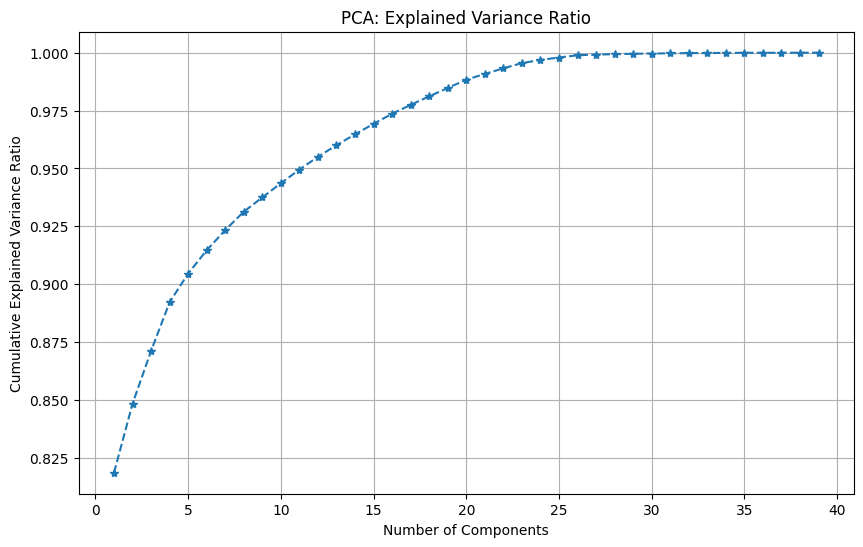

In [335]:
from sklearn.decomposition import PCA

# # Assuming 'X' contains your features
# pca = PCA(n_components= 23)
# pca.fit(X_train)

#Assuming 'X' contains your features
pca = PCA()
pca.fit(X_trainResampled)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_.cumsum(), marker='*', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA: Explained Variance Ratio')
plt.grid(True)
plt.show()

In [336]:
#apply the optimal n_components to a new pca.
#optimal number would be something where the graph levels off.
#in our case we might wanna keep it to 95% explained variance because at the point of 20 components, it's giving unnatural results.

#components = 11
components = 25

pca = PCA(n_components= components)

X_train_pca = pca.fit_transform(X_trainResampled)   #resampled and pca both done.
X_test_pca = pca.transform(X_test)

In [337]:
X_train_pca

array([[-1.04305681e+01, -2.55540765e-01,  1.20165420e+00, ...,
        -8.03863879e-02,  6.73391761e-02, -2.78304864e-04],
       [ 2.15516330e+01, -6.43051931e-01,  2.89809227e+00, ...,
        -7.65723542e-02,  9.54226026e-02,  5.52066203e-02],
       [ 2.15062187e+01, -6.34783926e-01,  2.97450325e+00, ...,
        -1.01854874e-01,  1.65688339e-01,  1.05346239e-01],
       ...,
       [-2.21017682e+00,  1.84355069e+00, -3.03224101e+00, ...,
        -1.31384603e+00, -2.63192618e-01,  1.41129257e-01],
       [-2.21668262e+00,  1.63142640e+00, -1.45109110e+00, ...,
         9.39804398e-01,  5.09622650e-01,  7.84402345e-02],
       [ 2.03921511e+01,  3.35265297e+00, -3.92564257e-01, ...,
         1.22547657e+00, -1.73574492e+00,  3.17632452e-01]])

In [338]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score,roc_curve
from sklearn.model_selection import cross_val_score


def model_eval(model,X_train, y_train, X_test, y_test):
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

    print(f"ROC AUC: {scores.mean():.4f} (+/- {scores.std():.4f})\n")

    #calculate training accuracy
    trainPred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, trainPred)
    print(f"\nThe training accuracy of the model will be: {np.round(accuracy_score(y_train, trainPred), 3)*100}%\n")

    # #calculate validation accuracy
    # valPred = model.predic)
    # val_accuracy = accuracy_score(, valPred)
    # print(f"The validation accuracy of the model will be: {np.round(accuracy_score(, valPred), 3)*100}%\n")

    testPred = model.predict(X_test)

    model_name = type(model).__name__

    print(f"{model_name} testing report on unseen data")
    print(classification_report(y_test, testPred))
    print("The confusion matrix will be: \n")
    print(confusion_matrix(y_test, testPred))
    # print(f"The ROC-AUC score on the testing data will be: {np.round(roc_auc_score(y_test, testPred), 3)}\n")


    # fpr, tpr, thresholds = roc_curve(y_test, testPred)
    # plt.plot(fpr, tpr)
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')

    print(f"\nThe testing accuracy of the model on unseen data will be: {np.round(accuracy_score(y_test, testPred), 3)*100}%\n")

In [339]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression

# Calculate class weights for imbalance handling
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

# Initialize and train Logistic Regression model with class weights and L2 regularization
lrL2 = LogisticRegression(penalty='l2', C=1.0, class_weight=dict(enumerate(class_weights)), random_state=42, multi_class='multinomial')
lrL2.fit(X_train_pca, y_trainResampled)

model_eval(lrL2, X_train_pca, y_trainResampled, X_test_pca, y_test)


ROC AUC: nan (+/- nan)


The training accuracy of the model will be: 97.7%

LogisticRegression testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     78355
           1       0.97      0.95      0.96     19353
           2       0.75      0.95      0.84       850
           3       0.35      0.93      0.51       235
           4       0.02      0.92      0.05        12

    accuracy                           0.98     98805
   macro avg       0.62      0.95      0.67     98805
weighted avg       0.99      0.98      0.99     98805

The confusion matrix will be: 

[[77732   445    73   102     3]
 [   32 18386   189   301   445]
 [    0    35   806     0     9]
 [    0    14     0   218     3]
 [    0     0     0     1    11]]

The testing accuracy of the model on unseen data will be: 98.3%



In [340]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="multi:softprob", random_state=42)
xgb_model.fit(X_train_pca, y_trainResampled)

model_eval(xgb_model, X_train_pca, y_trainResampled, X_test_pca, y_test)

ROC AUC: nan (+/- nan)


The training accuracy of the model will be: 100.0%

XGBClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     78355
           1       1.00      1.00      1.00     19353
           2       0.99      0.99      0.99       850
           3       0.97      0.82      0.89       235
           4       0.91      0.83      0.87        12

    accuracy                           1.00     98805
   macro avg       0.97      0.93      0.95     98805
weighted avg       1.00      1.00      1.00     98805

The confusion matrix will be: 

[[78350     5     0     0     0]
 [    4 19339     5     5     0]
 [    0    11   839     0     0]
 [    1    40     0   193     1]
 [    0     1     0     1    10]]

The testing accuracy of the model on unseen data will be: 99.9%



In [341]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train_pca, y_trainResampled)

model_eval(dtc, X_train_pca, y_trainResampled, X_test_pca, y_test)

ROC AUC: nan (+/- nan)


The training accuracy of the model will be: 100.0%

DecisionTreeClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     78355
           1       1.00      1.00      1.00     19353
           2       0.98      0.98      0.98       850
           3       0.92      0.82      0.87       235
           4       0.54      0.58      0.56        12

    accuracy                           1.00     98805
   macro avg       0.89      0.88      0.88     98805
weighted avg       1.00      1.00      1.00     98805

The confusion matrix will be: 

[[78347     7     1     0     0]
 [   32 19287    15    14     5]
 [    1    17   832     0     0]
 [    0    41     0   193     1]
 [    0     3     0     2     7]]

The testing accuracy of the model on unseen data will be: 99.9%



In [342]:
from sklearn.naive_bayes import BernoulliNB

# Train Gaussian Naive Baye Model
BNB_Classifier = BernoulliNB()
BNB_Classifier.fit(X_train_pca, y_trainResampled)

model_eval(BNB_Classifier, X_train_pca, y_trainResampled, X_test_pca, y_test)

ROC AUC: nan (+/- nan)


The training accuracy of the model will be: 91.5%

BernoulliNB testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      0.88      0.94     78355
           1       0.68      0.97      0.80     19353
           2       0.38      0.55      0.44       850
           3       0.25      0.68      0.36       235
           4       0.43      0.50      0.46        12

    accuracy                           0.90     98805
   macro avg       0.55      0.71      0.60     98805
weighted avg       0.93      0.90      0.90     98805

The confusion matrix will be: 

[[69026  8827   501     1     0]
 [   76 18791   272   207     7]
 [   22    93   464   271     0]
 [    3    72     0   159     1]
 [    0     6     0     0     6]]

The testing accuracy of the model on unseen data will be: 89.5%



In [343]:
from sklearn.ensemble import RandomForestClassifier

rfcFinal = RandomForestClassifier(n_jobs= -1, n_estimators= 35, criterion= "entropy")
rfcFinal.fit(X_train_pca, y_trainResampled)

model_eval(rfcFinal, X_train_pca, y_trainResampled, X_test_pca, y_test)

ROC AUC: nan (+/- nan)


The training accuracy of the model will be: 100.0%

RandomForestClassifier testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     78355
           1       1.00      1.00      1.00     19353
           2       1.00      0.98      0.99       850
           3       0.99      0.81      0.89       235
           4       0.88      0.58      0.70        12

    accuracy                           1.00     98805
   macro avg       0.97      0.88      0.92     98805
weighted avg       1.00      1.00      1.00     98805

The confusion matrix will be: 

[[78348     7     0     0     0]
 [    2 19346     4     1     0]
 [    0    16   834     0     0]
 [    0    43     0   191     1]
 [    0     4     0     1     7]]

The testing accuracy of the model on unseen data will be: 99.9%



In [344]:
from sklearn.svm import LinearSVC

newSVM = LinearSVC()
newSVM.fit(X_train_pca, y_trainResampled)

model_eval(newSVM, X_train_pca, y_trainResampled, X_test_pca, y_test)

ROC AUC: nan (+/- nan)


The training accuracy of the model will be: 99.6%

LinearSVC testing report on unseen data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     78355
           1       0.98      1.00      0.99     19353
           2       0.98      0.83      0.90       850
           3       0.81      0.33      0.47       235
           4       0.33      0.08      0.13        12

    accuracy                           1.00     98805
   macro avg       0.82      0.65      0.70     98805
weighted avg       1.00      1.00      0.99     98805

The confusion matrix will be: 

[[78252   103     0     0     0]
 [   17 19303    18    13     2]
 [    6   133   706     5     0]
 [    3   154     0    78     0]
 [    1    10     0     0     1]]

The testing accuracy of the model on unseen data will be: 99.5%

